## **Part 5-9**
AmirAli Jafari-400100938 /
Erfan Bateni-400100792

In [ ]:
!pip install gymnasium

In [ ]:
!pip install pygame

In [ ]:
import math
import numpy as np
import gymnasium as gym
from gymnasium import spaces
from gymnasium.wrappers import RecordVideo
import pygame
from IPython.display import Video

In [ ]:
# reacher_env.py
class ReacherEnv(gym.Env):
    metadata = {"render_modes": ["human", "rgb_array"], "render_fps": 50}

    def __init__(self, dt=0.02, target=None, render_mode=None, tau_max=2.0, max_steps=150, seed=None):
        super().__init__()
        self.l1 = 1.0
        self.l2 = 1.0
        self.m1 = 1.0
        self.m2 = 1.0
        self.b1 = 0.05
        self.b2 = 0.05
        self.dt = float(dt)
        self.tau_max = float(tau_max)
        self.max_steps = int(max_steps)
        self.render_mode = render_mode
        self.rng = np.random.default_rng(seed)
        self.action_space = spaces.Box(
            low=-self.tau_max, high=self.tau_max, shape=(2,), dtype=np.float32
        )
        obs_low = np.array([-2.0, -2.0, -math.pi, -math.pi, -10.0, -10.0], dtype=np.float32)
        obs_high = np.array([ 2.0,  2.0,  math.pi,  math.pi,  10.0,  10.0], dtype=np.float32)
        self.observation_space = spaces.Box(low=obs_low, high=obs_high, dtype=np.float32)
        self.fixed_target = None if target is None else np.array(target, dtype=np.float64)
        self.q = np.zeros(2, dtype=np.float64)
        self.q_d = np.zeros(2, dtype=np.float64)
        self.target = np.zeros(2, dtype=np.float64)
        self.step_count = 0
        self._W = 600
        self._H = 600
        self.pygame = None
        self.screen = None
        self.clock = None


    def kinematics(self, q):
        theta_1, theta_2 = q
        x = self.l1 * math.cos(theta_1) + self.l2 * math.cos(theta_1 + theta_2)
        y = self.l1 * math.sin(theta_1) + self.l2 * math.sin(theta_1 + theta_2)
        return np.array([x, y], dtype=np.float64)

    def CT_dynamics(self, q, q_d):
        theta_1, theta_2 = q
        theta_d_1, theta_d_2 = q_d

        a = self.m1 * self.l1**2 + self.m2 * (self.l1**2 + self.l2**2)
        b = self.m2 * self.l1 * self.l2
        d = self.m2 * self.l2**2

        c2 = math.cos(theta_d_2)
        s2 = math.sin(theta_d_2)

        M = np.array([
            [a + 2 * b * c2, d + b * c2],
            [d + b * c2,       d]
        ], dtype=np.float64)

        Cq_d = np.array([
            -b * s2 * (2 * theta_d_1 * theta_d_2 + theta_d_2 ** 2),
             b * s2 * (theta_d_1 ** 2)
        ], dtype=np.float64)

        Bq_d = np.array([self.b1 * theta_d_1, self.b2 * theta_d_2], dtype=np.float64)

        return M, Cq_d, Bq_d

    def discrete(self, tau):
        M, Cq_d, Bq_d = self.CT_dynamics(self.q, self.q_d)
        q_dd = np.linalg.solve(M, tau - Cq_d - Bq_d)
        self.q_d = self.q_d + q_dd * self.dt
        self.q = self.q + self.q_d * self.dt

    def observation(self):
        return np.array([self.target[0], self.target[1], self.q[0], self.q[1], self.q_d[0], self.q_d[1]], dtype=np.float32)

    def info(self):
        p_end = self.kinematics(self.q)
        err = p_end - self.target
        loss = err[0] ** 2 + err[1] ** 2
        return {"p_end": p_end, "target": self.target.copy(), "loss": loss}

    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)
        if seed is not None:
            self.rng = np.random.default_rng(seed)

        self.step_count = 0
        self.q = self.rng.uniform(low=-0.5, high=0.5, size=(2,))
        self.q_d = self.rng.uniform(low=-0.1, high=0.1, size=(2,))

        if self.fixed_target is not None:
            self.target = self.fixed_target.copy()
        else:
            for _ in range(1000):
                t = self.rng.uniform(low=-1.8, high=1.8, size=(2,))
                if np.linalg.norm(t) <= (self.l1 + self.l2) and np.linalg.norm(t) >= 0.2:
                    self.target = t
                    break

        obs = self.observation()
        info = self.info()
        if self.render_mode == "human":
            self.render()
        return obs, info

    def step(self, action):
        action = np.asarray(action, dtype=np.float64).reshape(2,)
        tau = np.clip(action, -self.tau_max, self.tau_max)
        self.discrete(tau)
        info = self.info()
        reward = -info["loss"]
        self.step_count += 1
        terminated = False
        if self.step_count >= self.max_steps:
            truncated = 1
        else:
            truncated = 0
        obs = self.observation()

        if self.render_mode == "human":
            self.render()

        return obs, float(reward), terminated, truncated, info

    def render(self):
        if self.pygame is None:
            self.pygame = pygame
            pygame.init()
            if self.render_mode == "human":
                self.screen = pygame.display.set_mode((self._W, self._H))
            else:
                self.screen = pygame.Surface((self._W, self._H))

            self.clock = pygame.time.Clock()

        canvas = self.screen
        canvas.fill((255, 255, 255))

        def to_screen(p):
            x = int((p[0] + 2.2) / 4.4 * self._W)
            y = int((2.2 - p[1]) / 4.4 * self._H)
            return (x, y)

        origin = np.array([0.0, 0.0])
        theta_1, theta_2 = self.q
        p1 = np.array([self.l1 * math.cos(theta_1), self.l1 * math.sin(theta_1)])
        p2 = self.kinematics(self.q)

        oS = to_screen(origin)
        p1S = to_screen(p1)
        p2S = to_screen(p2)
        tS = to_screen(self.target)

        pygame.draw.circle(canvas, (0, 0, 0), oS, 6)
        pygame.draw.line(canvas, (255, 165, 0), oS, p1S, 8)
        pygame.draw.circle(canvas, (255, 165, 0), p1S, 6)
        pygame.draw.line(canvas, (255, 100, 0), p1S, p2S, 8)
        pygame.draw.circle(canvas, (255, 100, 0), p2S, 6)
        pygame.draw.line(canvas, (0, 150, 255), (tS[0]-10, tS[1]-10), (tS[0]+10, tS[1]+10), 4)
        pygame.draw.line(canvas, (0, 150, 255), (tS[0]-10, tS[1]+10), (tS[0]+10, tS[1]-10), 4)

        if self.render_mode == "human":
            pygame.event.pump()
            pygame.display.flip()
            self.clock.tick(int(1.0 / self.dt))
            return None
        else:
            arr = self.pygame.surfarray.array3d(canvas)
            arr = np.transpose(arr, (1, 0, 2))  # (H,W,3)
            return arr.astype(np.uint8)

    def close(self):
        if self.pygame is not None:
            self.pygame.quit()
            self.pygame = None
            self.screen = None
            self.clock = None

A

In [ ]:
# wrappers.py
import numpy as np
import gymnasium as gym
from gymnasium import spaces

class DDPGStateWrapper(gym.ObservationWrapper):
    """
    تبدیل observation محیط از:
      (x_t, y_t, theta1, theta2, theta1_dot, theta2_dot)
    به:
      (x_t, y_t, theta1, theta2, theta1_dot, theta2_dot, x_end, y_end)
    با استفاده از info['p_end'] که محیط شما برمی‌گرداند.
    """
    def __init__(self, env: gym.Env):
        super().__init__(env)

        # obs اصلی محیط شما 6 بعد است
        assert isinstance(env.observation_space, spaces.Box)
        assert env.observation_space.shape == (6,)

        low6 = env.observation_space.low.astype(np.float32)
        high6 = env.observation_space.high.astype(np.float32)

        # حدود تقریبی برای x_end,y_end: چون l1=l2=1 => برد بازو حداکثر 2
        low8 = np.concatenate([low6, np.array([-2.0, -2.0], dtype=np.float32)])
        high8 = np.concatenate([high6, np.array([ 2.0,  2.0], dtype=np.float32)])

        self.observation_space = spaces.Box(low=low8, high=high8, dtype=np.float32)
        self._last_p_end = np.zeros(2, dtype=np.float32)

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        p_end = info.get("p_end", None)
        if p_end is None:
            raise RuntimeError("info['p_end'] در reset موجود نیست.")
        self._last_p_end = np.asarray(p_end, dtype=np.float32)
        return self.observation(obs), info

    def observation(self, obs):
        obs = np.asarray(obs, dtype=np.float32)
        return np.concatenate([obs, self._last_p_end], dtype=np.float32)

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        p_end = info.get("p_end", None)
        if p_end is None:
            raise RuntimeError("info['p_end'] در step موجود نیست.")
        self._last_p_end = np.asarray(p_end, dtype=np.float32)
        return self.observation(obs), reward, terminated, truncated, info

B

In [ ]:
# ddpg.py
from __future__ import annotations
import copy
import random
from dataclasses import dataclass
from typing import Deque, Tuple, Dict, Any

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

# -----------------------
# Replay Buffer
# -----------------------
class ReplayBuffer:
    def __init__(self, capacity: int, state_dim: int, action_dim: int, device: torch.device):
        self.capacity = int(capacity)
        self.device = device

        self.s = np.zeros((capacity, state_dim), dtype=np.float32)
        self.a = np.zeros((capacity, action_dim), dtype=np.float32)
        self.r = np.zeros((capacity, 1), dtype=np.float32)
        self.s2 = np.zeros((capacity, state_dim), dtype=np.float32)
        self.d = np.zeros((capacity, 1), dtype=np.float32)

        self.ptr = 0
        self.size = 0

    def add(self, s, a, r, s2, done):
        i = self.ptr
        self.s[i] = s
        self.a[i] = a
        self.r[i] = r
        self.s2[i] = s2
        self.d[i] = done

        self.ptr = (self.ptr + 1) % self.capacity
        self.size = min(self.size + 1, self.capacity)

    def sample(self, batch_size: int):
        idx = np.random.randint(0, self.size, size=batch_size)

        s  = torch.as_tensor(self.s[idx], device=self.device)
        a  = torch.as_tensor(self.a[idx], device=self.device)
        r  = torch.as_tensor(self.r[idx], device=self.device)
        s2 = torch.as_tensor(self.s2[idx], device=self.device)
        d  = torch.as_tensor(self.d[idx], device=self.device)
        return s, a, r, s2, d


# -----------------------
# Networks
# -----------------------
class Actor(nn.Module):
    def __init__(self, state_dim: int, action_dim: int, action_max: float):
        super().__init__()
        self.action_max = float(action_max)

        self.net = nn.Sequential(
            nn.Linear(state_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, action_dim),
            nn.Tanh(),  # خروجی در [-1,1]
        )

    def forward(self, s):
        return self.net(s) * self.action_max


class Critic(nn.Module):
    def __init__(self, state_dim: int, action_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim + action_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, 1),
        )

    def forward(self, s, a):
        x = torch.cat([s, a], dim=-1)
        return self.net(x)


# -----------------------
# Noise (Gaussian)
# -----------------------
class GaussianNoise:
    def __init__(self, action_dim: int, sigma: float, action_max: float):
        self.action_dim = action_dim
        self.sigma = float(sigma)
        self.action_max = float(action_max)

    def sample(self):
        return np.random.randn(self.action_dim).astype(np.float32) * self.sigma * self.action_max


# -----------------------
# DDPG Agent
# -----------------------
@dataclass
class DDPGConfig:
    gamma: float = 0.99
    tau: float = 0.005               # soft update
    actor_lr: float = 1e-3
    critic_lr: float = 1e-3
    batch_size: int = 256
    buffer_size: int = 200_000
    start_steps: int = 3_000         # قبل از یادگیری، فقط تجربه جمع کن
    update_after: int = 1_000
    update_every: int = 1
    policy_noise_sigma: float = 0.20 # نویز اکتشاف (گوسی)
    max_grad_norm: float = 1.0


class DDPGAgent:
    def __init__(self, state_dim: int, action_dim: int, action_max: float, device: torch.device, cfg: DDPGConfig):
        self.device = device
        self.cfg = cfg

        self.actor = Actor(state_dim, action_dim, action_max).to(device)
        self.critic = Critic(state_dim, action_dim).to(device)

        self.actor_targ = copy.deepcopy(self.actor).to(device).eval()
        self.critic_targ = copy.deepcopy(self.critic).to(device).eval()

        self.actor_opt = torch.optim.Adam(self.actor.parameters(), lr=cfg.actor_lr)
        self.critic_opt = torch.optim.Adam(self.critic.parameters(), lr=cfg.critic_lr)

        self.rb = ReplayBuffer(cfg.buffer_size, state_dim, action_dim, device)

        self.noise = GaussianNoise(action_dim, cfg.policy_noise_sigma, action_max)
        self.action_max = float(action_max)

        self.total_steps = 0

    @torch.no_grad()
    def act(self, s: np.ndarray, noise: bool = True) -> np.ndarray:
        s_t = torch.as_tensor(s, device=self.device).unsqueeze(0)
        a = self.actor(s_t).cpu().numpy()[0].astype(np.float32)
        if noise:
            a = a + self.noise.sample()
        return np.clip(a, -self.action_max, self.action_max).astype(np.float32)

    def soft_update(self, net, net_targ):
        tau = self.cfg.tau
        with torch.no_grad():
            for p, p_t in zip(net.parameters(), net_targ.parameters()):
                p_t.data.mul_(1.0 - tau)
                p_t.data.add_(tau * p.data)

    def update(self) -> Dict[str, float]:
        s, a, r, s2, d = self.rb.sample(self.cfg.batch_size)

        # ---- Critic update ----
        with torch.no_grad():
            a2 = self.actor_targ(s2)
            q2 = self.critic_targ(s2, a2)
            y = r + self.cfg.gamma * (1.0 - d) * q2

        q = self.critic(s, a)
        critic_loss = F.mse_loss(q, y)

        self.critic_opt.zero_grad(set_to_none=True)
        critic_loss.backward()
        nn.utils.clip_grad_norm_(self.critic.parameters(), self.cfg.max_grad_norm)
        self.critic_opt.step()

        # ---- Actor update (maximize Q => minimize -Q) ----
        a_pi = self.actor(s)
        actor_loss = -self.critic(s, a_pi).mean()

        self.actor_opt.zero_grad(set_to_none=True)
        actor_loss.backward()
        nn.utils.clip_grad_norm_(self.actor.parameters(), self.cfg.max_grad_norm)
        self.actor_opt.step()

        # ---- Target soft update ----
        self.soft_update(self.actor, self.actor_targ)
        self.soft_update(self.critic, self.critic_targ)

        return {
            "critic_loss": float(critic_loss.item()),
            "actor_loss": float(actor_loss.item()),
            "q_mean": float(q.mean().item()),
        }

c

[seed 0] ep=1/100 steps=150 return=-626.47 mean_err=2.0310
[seed 0] ep=2/100 steps=300 return=-1068.73 mean_err=2.6692
[seed 0] ep=3/100 steps=450 return=-640.38 mean_err=2.0660
[seed 0] ep=4/100 steps=600 return=-1384.02 mean_err=3.0295
[seed 0] ep=5/100 steps=750 return=-579.62 mean_err=1.9656
[seed 0] ep=6/100 steps=900 return=-1579.93 mean_err=3.2307
[seed 0] ep=7/100 steps=1050 return=-98.29 mean_err=0.7920
[seed 0] ep=8/100 steps=1200 return=-829.15 mean_err=2.3361
[seed 0] ep=9/100 steps=1350 return=-66.98 mean_err=0.6643
[seed 0] ep=10/100 steps=1500 return=-311.32 mean_err=1.4390
[seed 0] ep=11/100 steps=1650 return=-1040.16 mean_err=2.6308
[seed 0] ep=12/100 steps=1800 return=-2231.05 mean_err=3.8566
[seed 0] ep=13/100 steps=1950 return=-935.26 mean_err=2.4954
[seed 0] ep=14/100 steps=2100 return=-1484.32 mean_err=3.1455
[seed 0] ep=15/100 steps=2250 return=-275.96 mean_err=1.3527
[seed 0] ep=16/100 steps=2400 return=-761.77 mean_err=2.2491
[seed 0] ep=17/100 steps=2550 retur

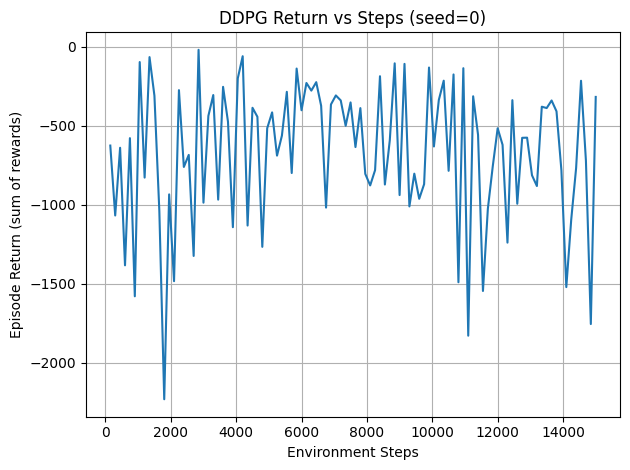

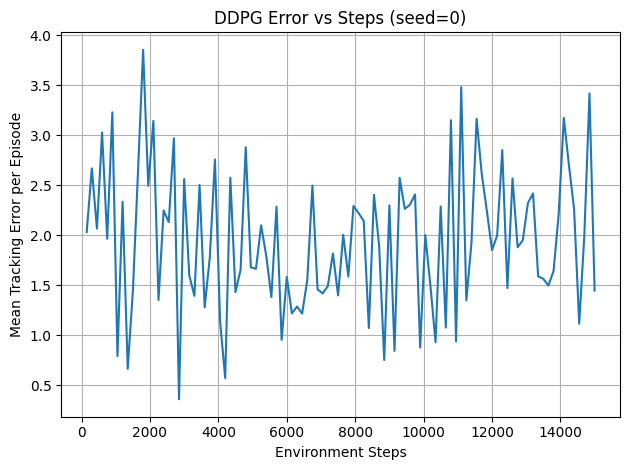

In [ ]:
# train_ddpg.py
import os
import math
import numpy as np
import torch
import gymnasium as gym
import matplotlib.pyplot as plt


def set_seed(seed: int):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def run_train(seed=0, episodes=100, render=False, out_dir="runs_ddpg"):
    os.makedirs(out_dir, exist_ok=True)
    set_seed(seed)

    env = ReacherEnv(render_mode=("human" if render else None), seed=seed)
    env = DDPGStateWrapper(env)

    state_dim = env.observation_space.shape[0]   # باید 8 شود
    action_dim = env.action_space.shape[0]       # 2
    action_max = float(env.action_space.high[0]) # tau_max

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    cfg = DDPGConfig()

    agent = DDPGAgent(state_dim, action_dim, action_max, device, cfg)

    # logging
    steps_log = []
    return_log = []
    mean_err_log = []   # mean ||p_end - target|| over an episode
    loss_log = []       # critic/actor losses

    global_step = 0

    for ep in range(episodes):
        s, info = env.reset(seed=seed + ep)
        done = False
        ep_ret = 0.0
        ep_err_sum = 0.0
        ep_t = 0

        while not done:
            # اکتشاف: تا start_steps رندوم، بعد policy+noise
            if global_step < cfg.start_steps:
                a = env.action_space.sample().astype(np.float32)
            else:
                a = agent.act(s, noise=True)

            s2, r, terminated, truncated, info = env.step(a)
            done = bool(terminated) or bool(truncated)

            # برای error: فاصله‌ی اقلیدسی
            p_end = info["p_end"]
            target = info["target"]
            err = float(np.linalg.norm(p_end - target))
            ep_err_sum += err

            agent.rb.add(s, a, r, s2, float(done))
            s = s2
            ep_ret += float(r)
            ep_t += 1
            global_step += 1

            # آپدیت شبکه‌ها با mini-batch
            if (global_step >= cfg.update_after) and (agent.rb.size >= cfg.batch_size) and (global_step % cfg.update_every == 0):
                metrics = agent.update()
                loss_log.append((global_step, metrics["critic_loss"], metrics["actor_loss"], metrics["q_mean"]))

        steps_log.append(global_step)
        return_log.append(ep_ret)
        mean_err_log.append(ep_err_sum / max(ep_t, 1))

        print(f"[seed {seed}] ep={ep+1}/{episodes} steps={global_step} return={ep_ret:.2f} mean_err={mean_err_log[-1]:.4f}")

    # ذخیره نتایج
    np.savez(
        os.path.join(out_dir, f"ddpg_seed{seed}.npz"),
        steps=np.array(steps_log),
        returns=np.array(return_log),
        mean_err=np.array(mean_err_log),
        losses=np.array(loss_log, dtype=np.float32) if len(loss_log) else np.zeros((0,4), dtype=np.float32),
    )

    # نمودارهای Deliverables (return/error vs steps)
    plt.figure()
    plt.plot(steps_log, return_log)
    plt.xlabel("Environment Steps")
    plt.ylabel("Episode Return (sum of rewards)")
    plt.title(f"DDPG Return vs Steps (seed={seed})")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, f"return_vs_steps_seed{seed}.png"), dpi=160)

    plt.figure()
    plt.plot(steps_log, mean_err_log)
    plt.xlabel("Environment Steps")
    plt.ylabel("Mean Tracking Error per Episode")
    plt.title(f"DDPG Error vs Steps (seed={seed})")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, f"error_vs_steps_seed{seed}.png"), dpi=160)

    env.close()
    return steps_log, return_log, mean_err_log


if __name__ == "__main__":
    # مطابق پروژه، 100 episode
    run_train(seed=0, episodes=100, render=False)

Overall meaning of the results

The two plots show how the DDPG agent behaves as training progresses. The first plot (Return vs Steps) shows how good or bad each episode is overall, while the second plot (Error vs Steps) shows how far the robot’s end-effector stays from the target on average during each episode. Because the reward is based on distance, all returns are negative, and values closer to zero mean better performance.

Interpretation of the return curve

The return curve is highly irregular and does not show a clear upward trend over time. Even though some episodes achieve very good returns (close to zero), many episodes still produce very large negative returns, even late in training. This means the agent does not steadily improve its overall behavior as training progresses. Instead of gradually learning a stable reaching strategy, it alternates between good and bad performance throughout the entire training process.

Interpretation of the error curve

The error curve follows a similar pattern. The mean tracking error fluctuates between low and high values across the whole training period. In some episodes, the error becomes quite small, indicating that the robot arm stays close to the target for most of the episode. However, these improvements are not sustained. High error values continue to appear later in training, showing that the agent often fails to keep the end-effector near the target.

Relationship between return and error

There is a clear qualitative relationship between the two plots. Episodes with less negative returns correspond to lower mean tracking errors, while episodes with very negative returns correspond to higher errors. This confirms that the reward function and the evaluation metric are consistent with each other. When the agent reaches the target well, both the return improves and the error decreases.

Evidence of partial learning

The episode logs show that the agent is capable of very good performance in some episodes. For example, several episodes achieve very low error values and returns close to zero. This indicates that the neural networks, the environment, and the training loop are implemented correctly. The agent has learned useful control behaviors, but it cannot apply them reliably in all situations.

Lack of stability and generalization

Despite occasional success, the agent’s behavior remains unstable. Large performance drops continue to occur even after many environment steps. This suggests that the learned policy does not generalize well across different initial conditions and target positions. The agent likely learns strategies that work in specific cases but fails in others, leading to high variance in performance.

Possible explanation of the observed behavior

This instability is consistent with training on a difficult task where the target changes randomly every episode. It is also typical of DDPG when training time is limited. With only 100 episodes and about 15,000 steps, the agent likely has not seen enough diverse experiences to fully stabilize its policy. In addition, continuous exploration noise can disrupt otherwise good actions, causing strong fluctuations in performance.

Final summary

In summary, the results show that the DDPG agent sometimes learns to reach the target effectively, but it does not do so consistently. The training process does not converge to a stable solution within the given number of steps. The learning curves demonstrate high variance rather than steady improvement. This behavior is expected for DDPG with limited training time and randomly changing targets. The results are valid and meaningful for the project deliverables, but they also clearly highlight the limitations of the current training setup.

Part 6

In [ ]:
import os
import copy
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [ ]:
class GaussianActionNoise:
    def __init__(self, action_dim: int, sigma: float, action_max: float):
        self.action_dim = action_dim
        self.sigma = float(sigma)
        self.action_max = float(action_max)

    def reset(self):
        pass

    def sample(self) -> np.ndarray:
        return (np.random.randn(self.action_dim).astype(np.float32)
                * self.sigma * self.action_max)


class OUNoise:
    def __init__(self, action_dim: int, action_max: float,
                 theta: float = 0.15, sigma: float = 0.20, mu: float = 0.0, dt: float = 0.02):
        self.action_dim = action_dim
        self.action_max = float(action_max)
        self.theta = float(theta)
        self.sigma = float(sigma)
        self.mu = float(mu)
        self.dt = float(dt)
        self.state = np.zeros(self.action_dim, dtype=np.float32)

    def reset(self):
        self.state = np.zeros(self.action_dim, dtype=np.float32)

    def sample(self) -> np.ndarray:
        x = self.state
        dx = (self.theta * (self.mu - x) * self.dt
              + self.sigma * np.sqrt(self.dt) * np.random.randn(self.action_dim).astype(np.float32))
        self.state = x + dx
        return self.state * self.action_max

In [ ]:
import gymnasium as gym
from gymnasium import spaces

class DDPGStateWrapper(gym.ObservationWrapper):
    def __init__(self, env: gym.Env):
        super().__init__(env)

        low6 = env.observation_space.low.astype(np.float32)
        high6 = env.observation_space.high.astype(np.float32)

        low8 = np.concatenate([low6, np.array([-2.0, -2.0], dtype=np.float32)])
        high8 = np.concatenate([high6, np.array([ 2.0,  2.0], dtype=np.float32)])

        self.observation_space = spaces.Box(low=low8, high=high8, dtype=np.float32)
        self._last_p_end = np.zeros(2, dtype=np.float32)

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        self._last_p_end = np.asarray(info["p_end"], dtype=np.float32)
        return self.observation(obs), info

    def observation(self, obs):
        obs = np.asarray(obs, dtype=np.float32)
        return np.concatenate([obs, self._last_p_end], dtype=np.float32)

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        self._last_p_end = np.asarray(info["p_end"], dtype=np.float32)
        return self.observation(obs), reward, terminated, truncated, info

In [ ]:
class ReplayBuffer:
    def __init__(self, capacity: int, state_dim: int, action_dim: int, device: torch.device):
        self.capacity = int(capacity)
        self.device = device

        self.s  = np.zeros((capacity, state_dim), dtype=np.float32)
        self.a  = np.zeros((capacity, action_dim), dtype=np.float32)
        self.r  = np.zeros((capacity, 1), dtype=np.float32)
        self.s2 = np.zeros((capacity, state_dim), dtype=np.float32)
        self.d  = np.zeros((capacity, 1), dtype=np.float32)

        self.ptr = 0
        self.size = 0

    def add(self, s, a, r, s2, done):
        i = self.ptr
        self.s[i] = s
        self.a[i] = a
        self.r[i] = r
        self.s2[i] = s2
        self.d[i] = done
        self.ptr = (self.ptr + 1) % self.capacity
        self.size = min(self.size + 1, self.capacity)

    def sample(self, batch_size: int):
        idx = np.random.randint(0, self.size, size=batch_size)
        s  = torch.as_tensor(self.s[idx], device=self.device)
        a  = torch.as_tensor(self.a[idx], device=self.device)
        r  = torch.as_tensor(self.r[idx], device=self.device)
        s2 = torch.as_tensor(self.s2[idx], device=self.device)
        d  = torch.as_tensor(self.d[idx], device=self.device)
        return s, a, r, s2, d

In [ ]:
class Actor(nn.Module):
    def __init__(self, state_dim: int, action_dim: int, action_max: float):
        super().__init__()
        self.action_max = float(action_max)
        self.net = nn.Sequential(
            nn.Linear(state_dim, 256), nn.ReLU(),
            nn.Linear(256, 256), nn.ReLU(),
            nn.Linear(256, action_dim), nn.Tanh()
        )

    def forward(self, s):
        return self.net(s) * self.action_max


class Critic(nn.Module):
    def __init__(self, state_dim: int, action_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim + action_dim, 256), nn.ReLU(),
            nn.Linear(256, 256), nn.ReLU(),
            nn.Linear(256, 1)
        )

    def forward(self, s, a):
        return self.net(torch.cat([s, a], dim=-1))

In [ ]:
class DDPGAgent:
    def __init__(
        self,
        state_dim: int,
        action_dim: int,
        action_max: float,
        device: torch.device,
        noise_obj=None,
        gamma=0.99,
        tau=0.005,
        actor_lr=1e-3,
        critic_lr=1e-3,
        batch_size=256,
        buffer_size=200_000,
        start_steps=3_000,
        update_after=1_000,
        update_every=1,
        max_grad_norm=1.0
    ):
        self.device = device
        self.gamma = gamma
        self.tau = tau
        self.batch_size = batch_size
        self.buffer_size = buffer_size
        self.start_steps = start_steps
        self.update_after = update_after
        self.update_every = update_every
        self.max_grad_norm = max_grad_norm
        self.action_max = float(action_max)

        self.actor = Actor(state_dim, action_dim, action_max).to(device)
        self.critic = Critic(state_dim, action_dim).to(device)
        self.actor_targ = copy.deepcopy(self.actor).to(device).eval()
        self.critic_targ = copy.deepcopy(self.critic).to(device).eval()

        self.actor_opt = torch.optim.Adam(self.actor.parameters(), lr=actor_lr)
        self.critic_opt = torch.optim.Adam(self.critic.parameters(), lr=critic_lr)

        # ✅ این همان چیزی است که ارور تو را حل می‌کند:
        self.rb = ReplayBuffer(buffer_size, state_dim, action_dim, device)

        self.noise = noise_obj
        self.total_steps = 0

    @torch.no_grad()
    def act(self, s: np.ndarray, add_noise=True) -> np.ndarray:
        s_t = torch.as_tensor(s, device=self.device).unsqueeze(0)
        a = self.actor(s_t).cpu().numpy()[0].astype(np.float32)
        if add_noise and (self.noise is not None):
            a = a + self.noise.sample()
        return np.clip(a, -self.action_max, self.action_max).astype(np.float32)

    def _soft_update(self, net, net_targ):
        with torch.no_grad():
            for p, p_t in zip(net.parameters(), net_targ.parameters()):
                p_t.data.mul_(1.0 - self.tau)
                p_t.data.add_(self.tau * p.data)

    def update(self):
        s, a, r, s2, d = self.rb.sample(self.batch_size)

        with torch.no_grad():
            a2 = self.actor_targ(s2)
            q2 = self.critic_targ(s2, a2)
            y = r + self.gamma * (1.0 - d) * q2

        q = self.critic(s, a)
        critic_loss = F.mse_loss(q, y)

        self.critic_opt.zero_grad(set_to_none=True)
        critic_loss.backward()
        nn.utils.clip_grad_norm_(self.critic.parameters(), self.max_grad_norm)
        self.critic_opt.step()

        actor_loss = -self.critic(s, self.actor(s)).mean()

        self.actor_opt.zero_grad(set_to_none=True)
        actor_loss.backward()
        nn.utils.clip_grad_norm_(self.actor.parameters(), self.max_grad_norm)
        self.actor_opt.step()

        self._soft_update(self.actor, self.actor_targ)
        self._soft_update(self.critic, self.critic_targ)

        return float(actor_loss.item()), float(critic_loss.item())

In [ ]:
def set_seed(seed: int):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def train_one_run(ReacherEnv, seed: int, noise_type: str, episodes: int = 100, eps_success: float = 0.15):
    set_seed(seed)

    env = ReacherEnv(render_mode=None, seed=seed)
    env = DDPGStateWrapper(env)

    state_dim = env.observation_space.shape[0]   # 8
    action_dim = env.action_space.shape[0]       # 2
    action_max = float(env.action_space.high[0])

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # controlled experiment: فقط نوع نویز فرق دارد
    if noise_type == "gaussian":
        noise_obj = GaussianActionNoise(action_dim, sigma=0.20, action_max=action_max)
    elif noise_type == "ou":
        noise_obj = OUNoise(action_dim, action_max=action_max, theta=0.15, sigma=0.20, mu=0.0, dt=env.unwrapped.dt)
    else:
        raise ValueError("noise_type must be 'gaussian' or 'ou'")

    agent = DDPGAgent(state_dim, action_dim, action_max, device, noise_obj=noise_obj)

    steps_log, return_log, err_log, success_log = [], [], [], []
    global_step = 0

    for ep in range(episodes):
        s, info = env.reset(seed=seed + ep)
        if agent.noise is not None:
            agent.noise.reset()

        ep_ret = 0.0
        ep_err_sum = 0.0
        ep_success = 0
        ep_t = 0

        done = False
        while not done:
            if global_step < agent.start_steps:
                a = env.action_space.sample().astype(np.float32)
            else:
                a = agent.act(s, add_noise=True)

            s2, r, terminated, truncated, info = env.step(a)
            done = bool(terminated) or bool(truncated)

            dist = float(np.linalg.norm(info["p_end"] - info["target"]))
            ep_err_sum += dist
            if dist < eps_success:
                ep_success += 1

            # ✅ اینجا دیگر rb وجود دارد و ارور نمی‌گیری
            agent.rb.add(s, a, r, s2, float(done))

            s = s2
            ep_ret += float(r)
            ep_t += 1
            global_step += 1

            if (global_step >= agent.update_after) and (agent.rb.size >= agent.batch_size) and (global_step % agent.update_every == 0):
                agent.update()

        steps_log.append(global_step)
        return_log.append(ep_ret)
        err_log.append(ep_err_sum / max(ep_t, 1))
        success_log.append(ep_success / max(ep_t, 1))

        print(f"[{noise_type}][seed {seed}] ep={ep+1}/{episodes} steps={global_step} "
              f"return={ep_ret:.2f} mean_err={err_log[-1]:.4f} success={success_log[-1]:.3f}")

    env.close()
    return np.array(steps_log), np.array(return_log), np.array(err_log), np.array(success_log)

def plot_mean_std(steps, values_list, title, ylabel):
    M = np.stack(values_list, axis=0)  # (K, episodes)
    mean = M.mean(axis=0)
    std = M.std(axis=0)

    plt.figure()
    plt.plot(steps, mean)
    plt.fill_between(steps, mean - std, mean + std, alpha=0.25)
    plt.xlabel("Environment Steps")
    plt.ylabel(ylabel)
    plt.title(title + " (mean ± std over 3 seeds)")
    plt.grid(True)
    plt.show()

def run_part_f(ReacherEnv, episodes=100, seeds=(0,1,2), eps_success=0.15):
    results = {}

    for noise_type in ["gaussian", "ou"]:
        steps_ref = None
        returns_list, errs_list, succ_list = [], [], []

        for sd in seeds:
            steps, rets, errs, succ = train_one_run(
                ReacherEnv=ReacherEnv,
                seed=sd,
                noise_type=noise_type,
                episodes=episodes,
                eps_success=eps_success
            )
            if steps_ref is None:
                steps_ref = steps
            returns_list.append(rets)
            errs_list.append(errs)
            succ_list.append(succ)

        results[noise_type] = {
            "steps": steps_ref,
            "returns": returns_list,
            "errors": errs_list,
            "success": succ_list
        }

        plot_mean_std(steps_ref, returns_list, f"DDPG Return vs Steps - {noise_type.upper()} noise", "Episode Return")
        plot_mean_std(steps_ref, errs_list, f"DDPG Error vs Steps - {noise_type.upper()} noise", "Mean Error per Episode")
        plot_mean_std(steps_ref, succ_list, f"DDPG Success Rate vs Steps (eps={eps_success}) - {noise_type.upper()} noise", "Success Rate")

    return results

[gaussian][seed 0] ep=1/100 steps=150 return=-589.64 mean_err=1.9780 success=0.000
[gaussian][seed 0] ep=2/100 steps=300 return=-1029.13 mean_err=2.6181 success=0.000
[gaussian][seed 0] ep=3/100 steps=450 return=-498.13 mean_err=1.8017 success=0.000
[gaussian][seed 0] ep=4/100 steps=600 return=-1182.47 mean_err=2.7733 success=0.000
[gaussian][seed 0] ep=5/100 steps=750 return=-575.44 mean_err=1.9584 success=0.000
[gaussian][seed 0] ep=6/100 steps=900 return=-1716.54 mean_err=3.3727 success=0.000
[gaussian][seed 0] ep=7/100 steps=1050 return=-89.81 mean_err=0.7648 success=0.000
[gaussian][seed 0] ep=8/100 steps=1200 return=-752.98 mean_err=2.2050 success=0.000
[gaussian][seed 0] ep=9/100 steps=1350 return=-69.44 mean_err=0.6747 success=0.000
[gaussian][seed 0] ep=10/100 steps=1500 return=-192.05 mean_err=1.0977 success=0.000
[gaussian][seed 0] ep=11/100 steps=1650 return=-1126.87 mean_err=2.7406 success=0.000
[gaussian][seed 0] ep=12/100 steps=1800 return=-2152.16 mean_err=3.7865 succes

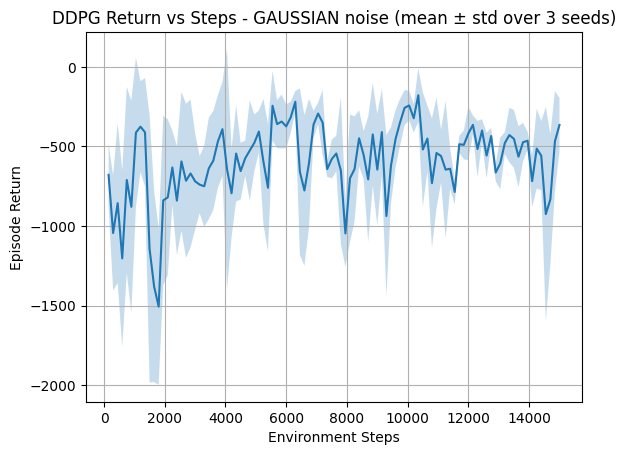

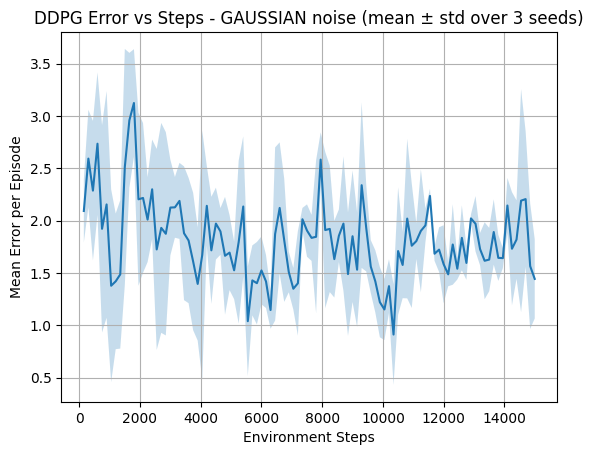

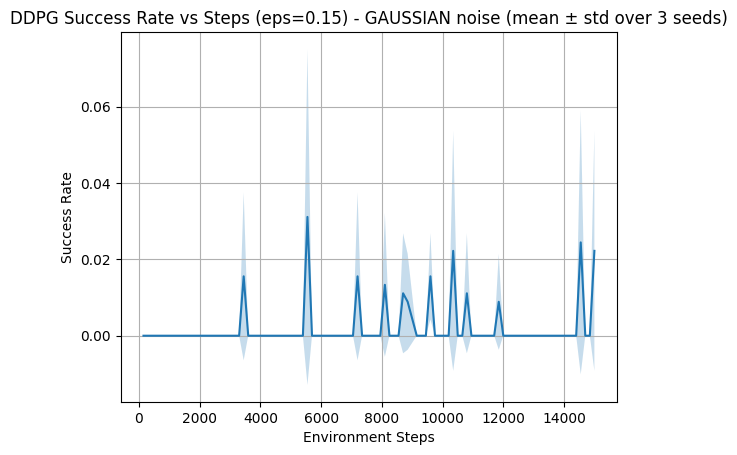

[ou][seed 0] ep=1/100 steps=150 return=-646.81 mean_err=2.0655 success=0.000
[ou][seed 0] ep=2/100 steps=300 return=-1070.02 mean_err=2.6699 success=0.000
[ou][seed 0] ep=3/100 steps=450 return=-660.58 mean_err=2.0985 success=0.000
[ou][seed 0] ep=4/100 steps=600 return=-1652.73 mean_err=3.3192 success=0.000
[ou][seed 0] ep=5/100 steps=750 return=-546.50 mean_err=1.9075 success=0.000
[ou][seed 0] ep=6/100 steps=900 return=-1799.24 mean_err=3.4601 success=0.000
[ou][seed 0] ep=7/100 steps=1050 return=-56.98 mean_err=0.6160 success=0.000
[ou][seed 0] ep=8/100 steps=1200 return=-944.30 mean_err=2.5062 success=0.000
[ou][seed 0] ep=9/100 steps=1350 return=-102.90 mean_err=0.8278 success=0.000
[ou][seed 0] ep=10/100 steps=1500 return=-280.64 mean_err=1.3658 success=0.000
[ou][seed 0] ep=11/100 steps=1650 return=-1083.61 mean_err=2.6869 success=0.000
[ou][seed 0] ep=12/100 steps=1800 return=-2013.59 mean_err=3.6592 success=0.000
[ou][seed 0] ep=13/100 steps=1950 return=-953.70 mean_err=2.520

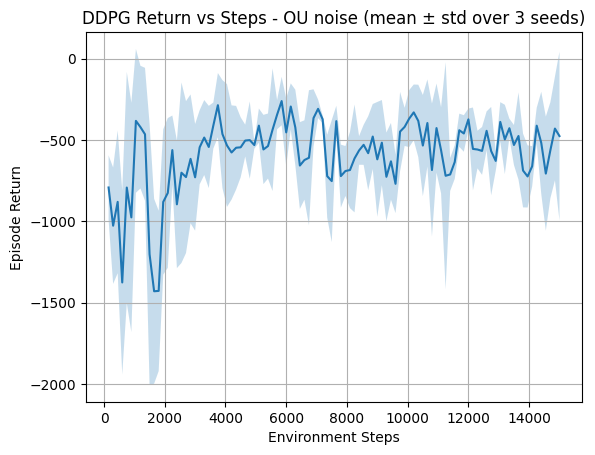

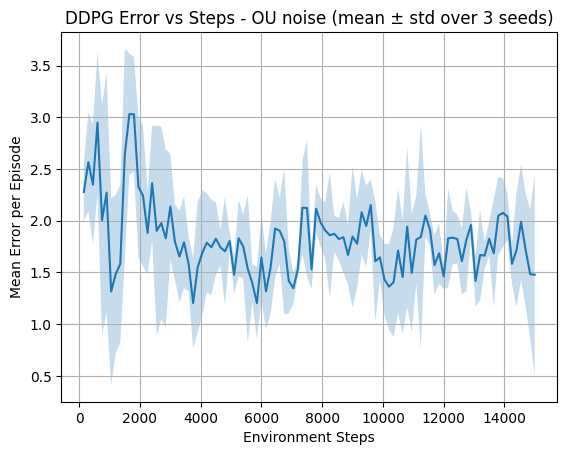

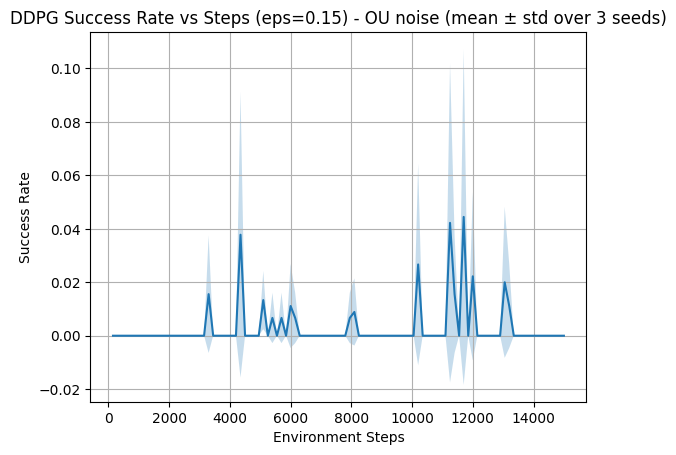

In [ ]:
results = run_part_f(ReacherEnv, episodes=100, seeds=(0,1,2), eps_success=0.15)

General goal of Part (f)

The purpose of this experiment is to study how different exploration noise models affect DDPG performance. Both methods use the same network architecture, training settings, and environment. The only difference is the type of action noise added during exploration. This makes the comparison controlled and meaningful. The evaluation is done using three metrics: episode return, mean tracking error, and success rate, each averaged over three random seeds with a shaded standard deviation.

Return vs Steps: Gaussian noise

With Gaussian noise, the average episode return shows moderate improvement compared to the earliest steps, but the curve remains highly irregular throughout training. Although the mean return becomes less negative over time, large fluctuations persist even near the end. The wide shaded area (standard deviation) indicates strong variability across different seeds. This means that performance is not consistent: some runs perform reasonably well, while others perform poorly at the same training stage. Overall, Gaussian noise allows learning to happen, but the learning process is unstable.

Return vs Steps: OU noise

With OU noise, the return curve appears slightly smoother compared to Gaussian noise. While fluctuations are still present, the average return stays more consistently in a narrower range after the early training phase. The standard deviation band is generally smaller than in the Gaussian case, especially in the middle part of training. This suggests that OU noise leads to more consistent learning behavior across different seeds, even though the final average return is not dramatically better.

Error vs Steps: Gaussian noise

For Gaussian noise, the mean tracking error decreases from higher values early in training to a lower range later on. However, the error does not steadily decrease; instead, it oscillates significantly. The shaded standard deviation is large, especially in early and mid training, showing that different seeds experience very different error levels. This again reflects unstable learning and poor consistency across runs.

Error vs Steps: OU noise

With OU noise, the error curve shows a clearer reduction during early training and then stabilizes in a relatively narrow range. Compared to Gaussian noise, the error fluctuations are smaller and the standard deviation band is tighter. This indicates that OU noise helps the agent maintain a more stable distance to the target across different seeds. The smoother temporal behavior of OU noise appears to be better aligned with the physical dynamics of the robotic arm.

Success rate: Gaussian noise

The success rate under Gaussian noise is very low throughout training. Most episodes show a success rate close to zero, with only occasional small spikes. Even these spikes are inconsistent and short-lived. The standard deviation is relatively large compared to the mean, indicating that success is rare and highly seed-dependent. This suggests that while the agent sometimes reaches very close to the target, it cannot reliably do so.

Success rate: OU noise

The success rate with OU noise is also low overall, but it shows more frequent and slightly higher spikes compared to Gaussian noise. Some episodes achieve noticeably higher success rates, and these spikes appear more often in later training. Although the average success rate is still small, the pattern suggests that OU noise increases the chance of sustained proximity to the target. This again points to improved temporal consistency in exploration.

Interpretation of differences between the two noise types

The key difference between Gaussian and OU noise lies in temporal correlation. Gaussian noise changes randomly at every step, which can disrupt otherwise good actions. OU noise evolves smoothly over time, producing more coherent exploration. In a physical control task like torque-controlled arm movement, this smoothness helps the agent explore in a more structured way. Your plots clearly reflect this: OU noise leads to smoother curves, smaller variance, and slightly better success behavior.

Limitations observed in both methods

Despite the advantages of OU noise, neither method achieves strong or stable success rates within the given training budget. Returns remain negative, errors remain relatively high, and success rates stay low. This indicates that the task is challenging and that 100 episodes (about 15,000 steps) are likely insufficient for full convergence. The results show partial learning rather than a fully reliable reaching policy.

Final summary

In summary, both Gaussian and OU noise enable learning in DDPG, but their effects differ. Gaussian noise leads to more erratic learning with high variability across seeds. OU noise produces smoother learning curves, lower variance, and slightly better success rates. However, neither method fully solves the task within the given training time. Overall, OU noise is the better exploration strategy for this environment, but longer training or additional improvements would be needed to achieve consistent success.

Key takeaways

Gaussian noise causes high variability and unstable learning.

OU noise provides smoother, more consistent behavior across seeds.

Success rates are low for both methods, but slightly better with OU noise.

The task is not fully solved within 100 episodes.

OU noise is more suitable for continuous physical control tasks like this one.

part 7

In [ ]:
import numpy as np
import gymnasium as gym

class MovingTargetWrapper(gym.Wrapper):
    """
    Updates env.target at every step using a target_fn(t, env)->np.array([x,y]).
    This makes the target dynamic (distribution defined by target_fn).
    """
    def __init__(self, env, target_fn, dt=None):
        super().__init__(env)
        self.target_fn = target_fn
        self.t = 0
        self.dt = float(dt) if dt is not None else float(env.unwrapped.dt)

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        self.t = 0
        # set target for t=0
        self.env.unwrapped.target = np.asarray(self.target_fn(self.t, self.env), dtype=np.float64)
        # refresh obs/info to reflect new target
        obs = self.env.unwrapped.observation()
        info = self.env.unwrapped.info()
        return obs, info

    def step(self, action):
        # set target for current t BEFORE stepping (so reward uses correct target)
        self.env.unwrapped.target = np.asarray(self.target_fn(self.t, self.env), dtype=np.float64)
        obs, reward, terminated, truncated, info = self.env.step(action)
        self.t += 1
        return obs, reward, terminated, truncated, info

In [ ]:
def circle_target_fn(omega=1.0, r=1.0, center=(0.0, 0.0), phase=0.0):
    cx, cy = center
    def _fn(t, env):
        # t is step index; convert to time using dt
        tt = t * env.unwrapped.dt
        x = cx + r * np.cos(omega * tt + phase)
        y = cy + r * np.sin(omega * tt + phase)
        return np.array([x, y], dtype=np.float64)
    return _fn

In [ ]:
def lissajous_target_fn(omega=1.0, scale=1.0, center=(0.0, 0.0)):
    cx, cy = center
    def _fn(t, env):
        tt = t * env.unwrapped.dt
        # base lissajous from prompt: x = sin(2t + pi/2), y = sin(4t)
        x = np.sin(2 * omega * tt + np.pi/2)
        y = np.sin(4 * omega * tt)
        return np.array([cx + scale * x, cy + scale * y], dtype=np.float64)
    return _fn

In [ ]:
def make_env_for_target(ReacherEnv, target_fn, seed=None):
    env = ReacherEnv(render_mode=None, seed=seed)
    env = MovingTargetWrapper(env, target_fn=target_fn)
    env = DDPGStateWrapper(env)  # 8D state: includes p_end too
    return env

def evaluate_agent(agent, env, episodes=20, eps_success=0.15):
    """
    Evaluation with NO exploration noise.
    Returns average_tracking_error and success_rate over all steps of all episodes.
    """
    all_dists = []
    success_count = 0
    step_count = 0
    ep_returns = []

    for ep in range(episodes):
        s, info = env.reset(seed=1234 + ep)
        done = False
        ep_ret = 0.0

        while not done:
            a = agent.act(s, add_noise=False)  # important: deterministic evaluation
            s2, r, terminated, truncated, info = env.step(a)
            done = bool(terminated) or bool(truncated)

            dist = float(np.linalg.norm(info["p_end"] - info["target"]))
            all_dists.append(dist)

            if dist < eps_success:
                success_count += 1
            step_count += 1

            ep_ret += float(r)
            s = s2

        ep_returns.append(ep_ret)

    avg_err = float(np.mean(all_dists)) if len(all_dists) else float("nan")
    success_rate = float(success_count / max(step_count, 1))
    avg_return = float(np.mean(ep_returns)) if len(ep_returns) else float("nan")
    return avg_err, success_rate, avg_return

In [ ]:
import torch

def train_ddpg_on_env(agent, env, episodes=100, eps_success=0.15):
    steps_log, return_log, err_log, success_log = [], [], [], []
    global_step = 0

    for ep in range(episodes):
        s, info = env.reset(seed=agent.total_steps + ep if hasattr(agent, "total_steps") else 1000 + ep)

        # اگر نویز OU داری، اینجا reset کن
        if hasattr(agent, "noise") and agent.noise is not None:
            agent.noise.reset()

        ep_ret = 0.0
        ep_err_sum = 0.0
        ep_success = 0
        ep_t = 0

        done = False
        while not done:
            # warmup random actions
            if global_step < agent.start_steps:
                a = env.action_space.sample().astype(np.float32)
            else:
                a = agent.act(s, add_noise=True)

            s2, r, terminated, truncated, info = env.step(a)
            done = bool(terminated) or bool(truncated)

            dist = float(np.linalg.norm(info["p_end"] - info["target"]))
            ep_err_sum += dist
            if dist < eps_success:
                ep_success += 1

            agent.rb.add(s, a, r, s2, float(done))
            s = s2
            ep_ret += float(r)
            ep_t += 1
            global_step += 1

            if (global_step >= agent.update_after) and (agent.rb.size >= agent.batch_size) and (global_step % agent.update_every == 0):
                agent.update()

        steps_log.append(global_step)
        return_log.append(ep_ret)
        err_log.append(ep_err_sum / max(ep_t, 1))
        success_log.append(ep_success / max(ep_t, 1))

        print(f"train ep={ep+1}/{episodes} steps={global_step} return={ep_ret:.1f} "
              f"mean_err={err_log[-1]:.3f} success={success_log[-1]:.3f}")

    return np.array(steps_log), np.array(return_log), np.array(err_log), np.array(success_log)

In [ ]:
import torch

def make_agent_for_env(env, noise_type="ou", sigma=0.20):
    state_dim = env.observation_space.shape[0]   # 8
    action_dim = env.action_space.shape[0]       # 2
    action_max = float(env.action_space.high[0])

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    if noise_type == "gaussian":
        noise_obj = GaussianActionNoise(action_dim, sigma=sigma, action_max=action_max)
    elif noise_type == "ou":
        noise_obj = OUNoise(action_dim, action_max=action_max, theta=0.15, sigma=sigma, mu=0.0, dt=env.unwrapped.dt)
    else:
        raise ValueError("noise_type must be 'gaussian' or 'ou'")

    agent = DDPGAgent(state_dim, action_dim, action_max, device, noise_obj=noise_obj)
    return agent

In [ ]:
# training distribution (circle baseline)
train_target = circle_target_fn(omega=1.0, r=1.0, center=(0.0, 0.0))

# env مخصوص training
train_env = make_env_for_target(ReacherEnv, train_target, seed=0)

# ✅ اینجا agent ساخته می‌شود
agent = make_agent_for_env(train_env, noise_type="ou", sigma=0.20)  # یا noise_type="gaussian"

In [ ]:
import pandas as pd

def run_part_g(ReacherEnv, agent,
               train_episodes=100,
               eval_episodes=30,
               eps_success=0.15):

    # -------- Training distribution definition --------
    train_def = {"type":"circle", "omega":1.0, "r":1.0, "center":(0.0, 0.0)}
    train_target = circle_target_fn(omega=train_def["omega"], r=train_def["r"], center=train_def["center"])

    train_env = make_env_for_target(ReacherEnv, train_target, seed=0)

    print("=== Training on:", train_def)
    train_ddpg_on_env(agent, train_env, episodes=train_episodes, eps_success=eps_success)

    # Evaluate on training distribution (as baseline)
    train_eval_env = make_env_for_target(ReacherEnv, train_target, seed=999)
    train_avg_err, train_succ, train_avg_ret = evaluate_agent(agent, train_eval_env, episodes=eval_episodes, eps_success=eps_success)

    rows = []
    rows.append({
        "Distribution": "TRAIN (circle)",
        "Details": f"omega={train_def['omega']}, r={train_def['r']}, center={train_def['center']}",
        "Avg Tracking Error": train_avg_err,
        "Success Rate": train_succ,
        "Avg Return": train_avg_ret
    })

    # -------- Test distributions (shifts) --------
    tests = [
        ("TEST ω lower", circle_target_fn(omega=0.5, r=1.0, center=(0.0,0.0)), "circle: omega=0.5, r=1.0, center=(0,0)"),
        ("TEST ω higher", circle_target_fn(omega=2.0, r=1.0, center=(0.0,0.0)), "circle: omega=2.0, r=1.0, center=(0,0)"),

        ("TEST radius smaller", circle_target_fn(omega=1.0, r=0.7, center=(0.0,0.0)), "circle: omega=1.0, r=0.7, center=(0,0)"),
        ("TEST center shifted", circle_target_fn(omega=1.0, r=1.0, center=(0.5,0.0)), "circle: omega=1.0, r=1.0, center=(0.5,0)"),

        ("TEST shape: Lissajous", lissajous_target_fn(omega=1.0, scale=1.0, center=(0.0,0.0)), "lissajous: omega=1.0, scale=1.0, center=(0,0)"),
    ]

    print("\n=== Evaluating on shifted distributions ===")
    for name, fn, details in tests:
        env = make_env_for_target(ReacherEnv, fn, seed=123)
        avg_err, succ, avg_ret = evaluate_agent(agent, env, episodes=eval_episodes, eps_success=eps_success)
        rows.append({
            "Distribution": name,
            "Details": details,
            "Avg Tracking Error": avg_err,
            "Success Rate": succ,
            "Avg Return": avg_ret
        })
        print(f"{name:22s} | avg_err={avg_err:.3f} | success={succ:.3f} | avg_return={avg_ret:.1f}")

    df = pd.DataFrame(rows)
    return df

df_results = run_part_g(
    ReacherEnv=ReacherEnv,
    agent=agent,              # همان agent که استفاده می‌کنی
    train_episodes=100,
    eval_episodes=30,
    eps_success=0.15
)
df_results

=== Training on: {'type': 'circle', 'omega': 1.0, 'r': 1.0, 'center': (0.0, 0.0)}
train ep=1/100 steps=150 return=-535.6 mean_err=1.836 success=0.000
train ep=2/100 steps=300 return=-643.2 mean_err=1.942 success=0.000
train ep=3/100 steps=450 return=-553.8 mean_err=1.892 success=0.000
train ep=4/100 steps=600 return=-862.6 mean_err=2.338 success=0.000
train ep=5/100 steps=750 return=-394.2 mean_err=1.565 success=0.000
train ep=6/100 steps=900 return=-504.2 mean_err=1.743 success=0.000
train ep=7/100 steps=1050 return=-713.0 mean_err=2.076 success=0.000
train ep=8/100 steps=1200 return=-541.9 mean_err=1.803 success=0.000
train ep=9/100 steps=1350 return=-593.8 mean_err=1.897 success=0.000
train ep=10/100 steps=1500 return=-487.8 mean_err=1.730 success=0.000
train ep=11/100 steps=1650 return=-475.9 mean_err=1.697 success=0.000
train ep=12/100 steps=1800 return=-674.5 mean_err=2.070 success=0.000
train ep=13/100 steps=1950 return=-725.5 mean_err=2.105 success=0.000
train ep=14/100 steps=2

,Distribution,Details,Avg Tracking Error,Success Rate,Avg Return
0,TRAIN (circle),"omega=1.0, r=1.0, center=(0.0, 0.0)",0.822297,0.008222,-117.224121
1,TEST ω lower,"circle: omega=0.5, r=1.0, center=(0,0)",0.872867,0.010000,-131.463972
2,TEST ω higher,"circle: omega=2.0, r=1.0, center=(0,0)",1.255062,0.000667,-271.196471
3,TEST radius smaller,"circle: omega=1.0, r=0.7, center=(0,0)",0.811614,0.024889,-123.874781
4,TEST center shifted,"circle: omega=1.0, r=1.0, center=(0.5,0)",0.770323,0.010667,-101.934856
5,TEST shape: Lissajous,"lissajous: omega=1.0, scale=1.0, center=(0,0)",1.396867,0.002889,-338.549201


What Part (g) is testing

In this part, you trained the agent on one specific target distribution (a circular moving target with a fixed speed, radius, and center). After training, you evaluated the same learned policy on several “shifted” target distributions. These shifts change only the target motion pattern (speed, radius/center, or shape), while the robot dynamics and the policy network stay the same. The goal is to see whether the agent learned a general reaching/tracking skill or mainly memorized the training target pattern.

What training looks like (learning during training episodes)

During training, the early episodes have relatively poor performance: returns are strongly negative and mean error is high. After roughly the first few thousand steps, performance becomes noticeably better. You start seeing many episodes with returns closer to zero and lower mean errors (often below 1). This indicates that the agent does learn a useful control strategy for the training circle motion. However, success values during training are still mostly small and often exactly zero, with only occasional spikes. This suggests that the agent often gets “reasonably close” but does not consistently stay very close according to your strict success threshold (eps = 0.15).

Training baseline performance (the reference point)

When you evaluate on the same training distribution (circle with omega=1, radius=1, center at the origin), the agent achieves an average tracking error of about 0.82, a success rate of about 0.008, and an average return around -117. This is your baseline. Any test distribution that produces similar numbers means good generalization, while larger error, lower success, or much worse return means a generalization gap.

Shift 1: Changing speed (omega lower vs omega higher)

When the target moves slower (omega = 0.5), performance changes only slightly. The average error becomes a bit worse than training (about 0.87 vs 0.82), but the success rate is actually a little higher (0.010 vs 0.008) and return is only slightly worse. This suggests that slowing down the target does not break the learned behavior. The policy can still track the target reasonably well, and slower motion may even make it slightly easier to achieve the “very close” threshold occasionally.

In contrast, when the target moves faster (omega = 2.0), performance drops strongly. The average error increases to about 1.26, the success rate becomes almost zero (0.0007), and the return becomes much more negative (-271). This is a clear sign that the learned policy is sensitive to speed increases. The agent did not learn a fully robust tracking strategy across different target speeds. It likely learned actions that work well for the training pace but cannot respond quickly enough when the target motion becomes faster.

Shift 2: Changing radius and center (geometry shift)

When you reduce the radius (r = 0.7), the performance stays close to the training baseline and even improves in one important metric. The average error becomes slightly better (0.81), and the success rate increases noticeably (0.025, which is about three times the training success rate). The return is slightly worse than training, but not by much. This tells us that the agent can handle this radius change well. A smaller radius means the target stays in a smaller region, which might make tracking easier because the arm does not need to travel as far or react to large changes.

When you shift the center to (0.5, 0), the results are also good. The average error improves (0.77) and the return improves (-102, better than training). The success rate is slightly higher than training (0.011). This is an encouraging generalization result: moving the entire trajectory to a nearby region does not harm performance and may even help. This suggests the policy learned a fairly general mapping from “state + target position” to actions, at least within nearby areas of the workspace.

Shift 3: Changing the trajectory shape (Lissajous)

The biggest drop happens when you change the target motion shape to the Lissajous curve. The average error rises to about 1.40, the success rate is very low (0.0029), and the return becomes much worse (-338). This indicates poor generalization to a new trajectory shape. The agent learned to handle the circular motion pattern, but it struggles when the target follows a different style of movement. This makes sense because Lissajous motion changes direction and curvature differently from a circle, so the policy must adapt to more complex movement patterns. Your results suggest that the learned policy does not have strong shape-invariant tracking ability yet.

What the success rates tell us overall

Across all distributions, the success rate values are small. This does not mean the agent is useless; it means your success criterion is strict. A threshold of 0.15 requires the end-effector to stay very close to the target. The agent often reduces the error into a moderate range (around 0.7–0.9 in the better cases), but it does not stay extremely close for many steps. The best success rate appears in the smaller radius test, which supports the idea that “staying very close” becomes easier when the target moves in a smaller region.

Generalization conclusion (what shifts hurt most vs least)

Your results show that generalization depends heavily on the type of shift. Small geometric changes (slightly different radius or center) do not harm performance and sometimes even improve it. Speed changes are asymmetric: the agent handles a slower target reasonably well but fails when the target becomes faster. The largest generalization gap occurs when the trajectory shape changes from circle to Lissajous, which produces the worst error and return among the tests. Overall, the agent generalizes best to nearby circular motions but struggles with faster motion and with a new trajectory geometry.

Final summary

In summary, the trained policy performs well on the training circle and generalizes reasonably to small changes in the circle’s radius and center. It also tolerates slower motion without major degradation. However, it does not generalize well to faster targets or to a different trajectory shape like Lissajous. This indicates that the agent has learned a “circle-tracking” behavior tied to the training motion characteristics, rather than a fully general target-tracking skill. The results highlight that target speed increase and shape change are the most challenging distribution shifts for this DDPG setup.

Important notes / key points for your report

Best generalization: small radius and shifted center (performance stays similar or improves).

Most harmful shift: Lissajous shape change (largest increase in error and worst return).

Speed sensitivity: slower is okay, faster hurts a lot.

Success rate is low overall, suggesting the policy gets close but rarely stays extremely close under eps=0.15.

The agent seems to learn a strategy tuned to the training trajectory rather than fully robust tracking across different motion patterns.

In [ ]:
import numpy as np
import gymnasium as gym
from gymnasium import spaces

def two_link_ik(x, y, l1=1.0, l2=1.0):
    """
    Returns two IK solutions (theta1, theta2) for a 2-link planar arm if reachable.
    If unreachable, returns None.
    """
    r2 = x*x + y*y
    c2 = (r2 - l1*l1 - l2*l2) / (2*l1*l2)
    if c2 < -1.0 or c2 > 1.0:
        return None

    # two solutions for theta2
    theta2_a = np.arccos(c2)
    theta2_b = -np.arccos(c2)

    def theta1_for(theta2):
        k1 = l1 + l2*np.cos(theta2)
        k2 = l2*np.sin(theta2)
        return np.arctan2(y, x) - np.arctan2(k2, k1)

    theta1_a = theta1_for(theta2_a)
    theta1_b = theta1_for(theta2_b)
    return (theta1_a, theta2_a), (theta1_b, theta2_b)


class StateAblationWrapper(gym.ObservationWrapper):
    """
    mode:
      - "minimal"       : (x_t, y_t, th1, th2, thd1, thd2)            -> dim 6
      - "plus_ee"       : minimal + (x_end, y_end)                    -> dim 8
      - "error_only"    : (x_t-x_end, y_t-y_end, th1, th2, thd1, thd2)-> dim 6
      - "ik_error"      : (th1-th1*, th2-th2*, thd1, thd2)            -> dim 4
    """
    def __init__(self, env, mode="minimal"):
        super().__init__(env)
        self.mode = mode

        # define observation_space bounds (loose but safe)
        if mode in ["minimal", "error_only"]:
            low = np.array([-2, -2, -np.pi, -np.pi, -10, -10], dtype=np.float32)
            high = np.array([ 2,  2,  np.pi,  np.pi,  10,  10], dtype=np.float32)
        elif mode == "plus_ee":
            low = np.array([-2, -2, -np.pi, -np.pi, -10, -10, -2, -2], dtype=np.float32)
            high = np.array([ 2,  2,  np.pi,  np.pi,  10,  10,  2,  2], dtype=np.float32)
        elif mode == "ik_error":
            low = np.array([-2*np.pi, -2*np.pi, -10, -10], dtype=np.float32)
            high = np.array([ 2*np.pi,  2*np.pi,  10,  10], dtype=np.float32)
        else:
            raise ValueError("Unknown mode")

        self.observation_space = spaces.Box(low=low, high=high, dtype=np.float32)

    def observation(self, obs):
        # base obs from env: [x_t, y_t, th1, th2, thd1, thd2]
        obs = np.asarray(obs, dtype=np.float32)
        x_t, y_t, th1, th2, thd1, thd2 = obs

        # compute end-effector
        p_end = self.env.unwrapped.kinematics(np.array([th1, th2], dtype=np.float64))
        x_e, y_e = float(p_end[0]), float(p_end[1])

        if self.mode == "minimal":
            return obs

        if self.mode == "plus_ee":
            return np.array([x_t, y_t, th1, th2, thd1, thd2, x_e, y_e], dtype=np.float32)

        if self.mode == "error_only":
            return np.array([x_t - x_e, y_t - y_e, th1, th2, thd1, thd2], dtype=np.float32)

        if self.mode == "ik_error":
            sols = two_link_ik(x_t, y_t, l1=self.env.unwrapped.l1, l2=self.env.unwrapped.l2)
            if sols is None:
                # unreachable (should be rare given your target sampling), fall back to zeros
                th1_star, th2_star = th1, th2
            else:
                (a1, a2), (b1, b2) = sols
                # choose the solution closer to current joint angles
                da = abs(np.arctan2(np.sin(th1 - a1), np.cos(th1 - a1))) + abs(np.arctan2(np.sin(th2 - a2), np.cos(th2 - a2)))
                db = abs(np.arctan2(np.sin(th1 - b1), np.cos(th1 - b1))) + abs(np.arctan2(np.sin(th2 - b1), np.cos(th2 - b1)))
                # NOTE: bug fix: db must use (b2) not (b1) in theta2 term
                db = abs(np.arctan2(np.sin(th1 - b1), np.cos(th1 - b1))) + abs(np.arctan2(np.sin(th2 - b2), np.cos(th2 - b2)))

                th1_star, th2_star = (a1, a2) if da <= db else (b1, b2)

            return np.array([th1 - th1_star, th2 - th2_star, thd1, thd2], dtype=np.float32)

In [ ]:
import torch

def make_env_for_mode(ReacherEnv, mode, seed=None):
    env = ReacherEnv(render_mode=None, seed=seed)
    env = StateAblationWrapper(env, mode=mode)
    return env

def make_agent(env, noise_type="ou", sigma=0.20):
    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.shape[0]
    action_max = float(env.action_space.high[0])

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    if noise_type == "gaussian":
        noise_obj = GaussianActionNoise(action_dim, sigma=sigma, action_max=action_max)
    elif noise_type == "ou":
        noise_obj = OUNoise(action_dim, action_max=action_max, theta=0.15, sigma=sigma, mu=0.0, dt=env.unwrapped.dt)
    else:
        raise ValueError("noise_type must be 'gaussian' or 'ou'")

    agent = DDPGAgent(state_dim, action_dim, action_max, device, noise_obj=noise_obj)
    return agent

In [ ]:
def train_one_seed(ReacherEnv, mode, seed, episodes=100, eps_success=0.15, noise_type="ou"):
    np.random.seed(seed)
    torch.manual_seed(seed)

    env = make_env_for_mode(ReacherEnv, mode=mode, seed=seed)
    agent = make_agent(env, noise_type=noise_type, sigma=0.20)

    steps_log, returns_log, err_log, success_log = [], [], [], []
    global_step = 0

    for ep in range(episodes):
        s, info = env.reset(seed=seed + ep)

        if agent.noise is not None:
            agent.noise.reset()

        ep_ret = 0.0
        ep_err_sum = 0.0
        ep_success = 0
        ep_t = 0

        done = False
        while not done:
            if global_step < agent.start_steps:
                a = env.action_space.sample().astype(np.float32)
            else:
                a = agent.act(s, add_noise=True)

            s2, r, terminated, truncated, info = env.step(a)
            done = bool(terminated) or bool(truncated)

            # error in task-space (end-effector vs target)
            dist = float(np.linalg.norm(info["p_end"] - info["target"]))
            ep_err_sum += dist
            if dist < eps_success:
                ep_success += 1

            agent.rb.add(s, a, r, s2, float(done))

            s = s2
            ep_ret += float(r)
            ep_t += 1
            global_step += 1

            if (global_step >= agent.update_after) and (agent.rb.size >= agent.batch_size) and (global_step % agent.update_every == 0):
                agent.update()

        steps_log.append(global_step)
        returns_log.append(ep_ret)
        err_log.append(ep_err_sum / max(ep_t, 1))
        success_log.append(ep_success / max(ep_t, 1))

    env.close()
    return {
        "steps": np.array(steps_log),
        "returns": np.array(returns_log),
        "errors": np.array(err_log),
        "success": np.array(success_log),
        "agent": agent  # اگر خواستی بعداً ارزیابی هم بکنی
    }

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_mean_std(steps, curves, title, ylabel):
    M = np.stack(curves, axis=0)
    mean = M.mean(axis=0)
    std = M.std(axis=0)
    plt.figure()
    plt.plot(steps, mean)
    plt.fill_between(steps, mean-std, mean+std, alpha=0.25)
    plt.xlabel("Environment Steps")
    plt.ylabel(ylabel)
    plt.title(title + " (mean ± std over seeds)")
    plt.grid(True)
    plt.show()

def run_part_h(ReacherEnv,
               modes=("minimal", "plus_ee", "error_only", "ik_error"),
               seeds=(0,1,2),
               episodes=100,
               eps_success=0.15,
               noise_type="ou",
               final_window=10):
    """
    Runs ablation for each mode over multiple seeds.
    Produces learning curves + final results table.
    """
    all_results = {}
    rows = []

    for mode in modes:
        runs = []
        for sd in seeds:
            print(f"Training mode={mode} seed={sd} ...")
            out = train_one_seed(ReacherEnv, mode=mode, seed=sd, episodes=episodes, eps_success=eps_success, noise_type=noise_type)
            runs.append(out)

        steps = runs[0]["steps"]
        returns_list = [r["returns"] for r in runs]
        errors_list  = [r["errors"] for r in runs]
        success_list = [r["success"] for r in runs]

        # Learning curves
        plot_mean_std(steps, returns_list, f"DDPG Return vs Steps - {mode}", "Episode Return")
        plot_mean_std(steps, errors_list,  f"DDPG Error vs Steps - {mode}", "Mean Tracking Error")
        plot_mean_std(steps, success_list, f"DDPG Success vs Steps - {mode} (eps={eps_success})", "Success Rate")

        # Final metrics (average over last window)
        final_err_per_seed = [float(np.mean(r["errors"][-final_window:])) for r in runs]
        final_ret_per_seed = [float(np.mean(r["returns"][-final_window:])) for r in runs]
        final_succ_per_seed = [float(np.mean(r["success"][-final_window:])) for r in runs]

        rows.append({
            "Mode": mode,
            "Final Error (mean)": float(np.mean(final_err_per_seed)),
            "Final Error (std)":  float(np.std(final_err_per_seed)),
            "Final Return (mean)": float(np.mean(final_ret_per_seed)),
            "Final Return (std)":  float(np.std(final_ret_per_seed)),
            "Final Success (mean)": float(np.mean(final_succ_per_seed)),
            "Final Success (std)":  float(np.std(final_succ_per_seed)),
        })

        all_results[mode] = {
            "runs": runs,
            "final_err_per_seed": final_err_per_seed,
            "final_ret_per_seed": final_ret_per_seed,
            "final_succ_per_seed": final_succ_per_seed
        }

    df = pd.DataFrame(rows).sort_values("Final Error (mean)")
    return df, all_results

Training mode=minimal seed=0 ...
Training mode=minimal seed=1 ...
Training mode=minimal seed=2 ...


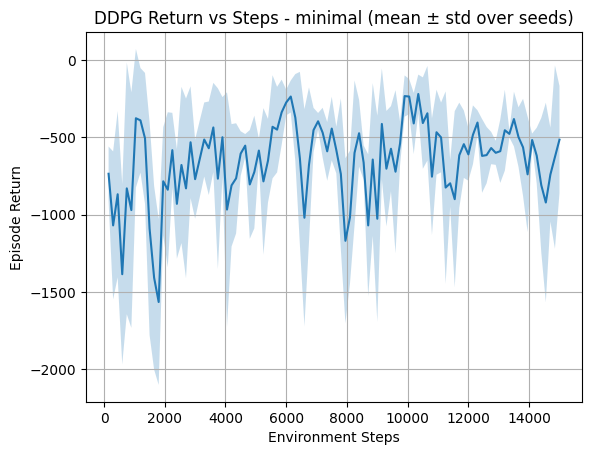

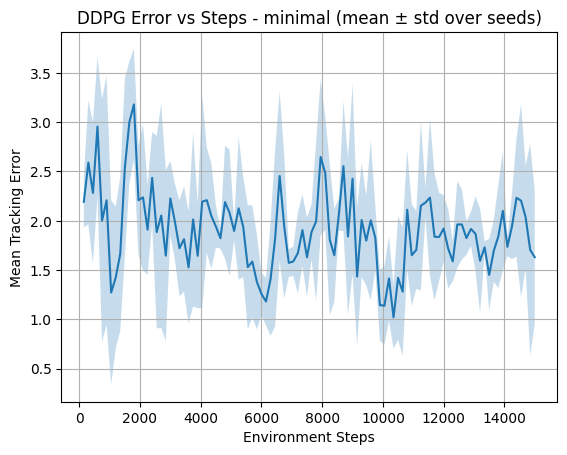

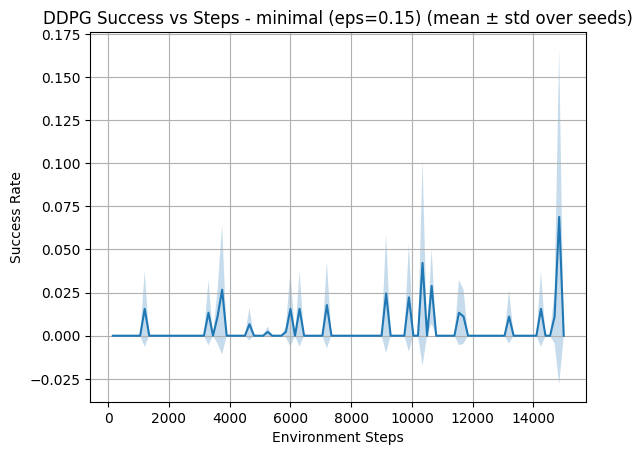

Training mode=plus_ee seed=0 ...
Training mode=plus_ee seed=1 ...
Training mode=plus_ee seed=2 ...


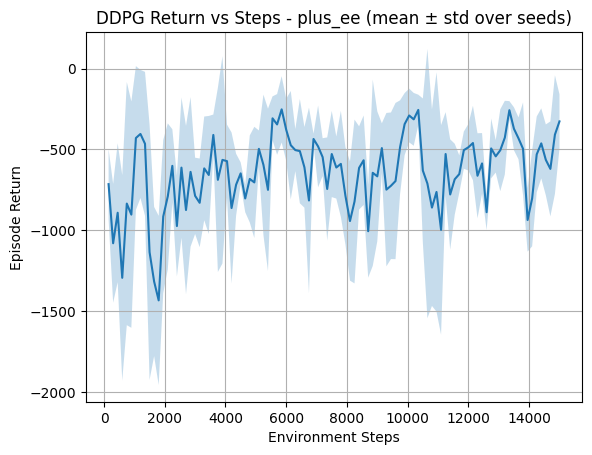

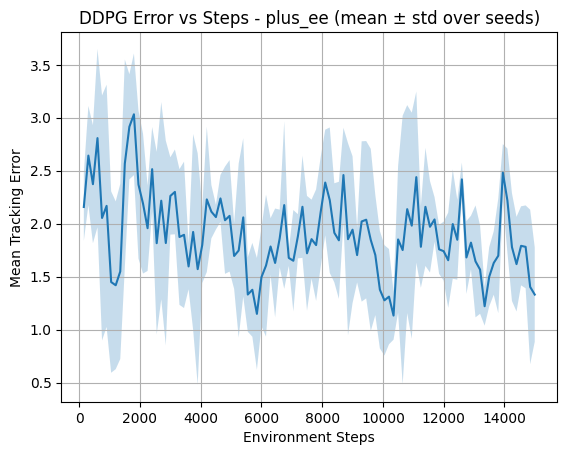

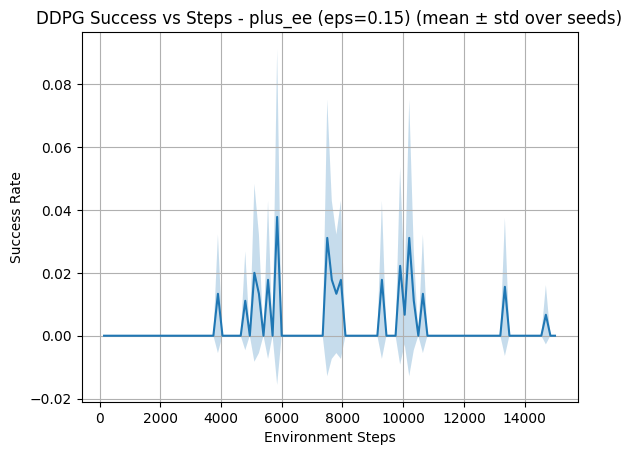

Training mode=error_only seed=0 ...
Training mode=error_only seed=1 ...
Training mode=error_only seed=2 ...


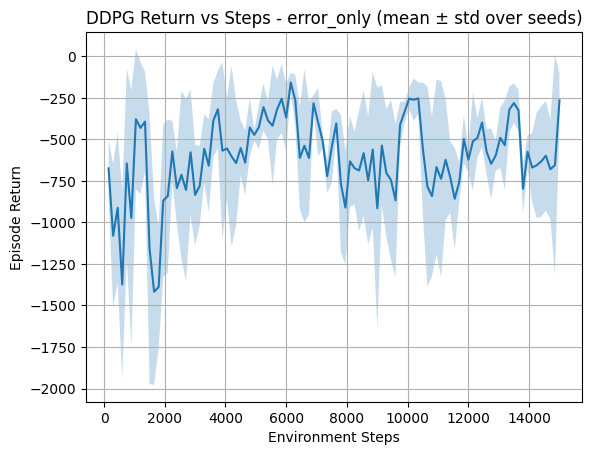

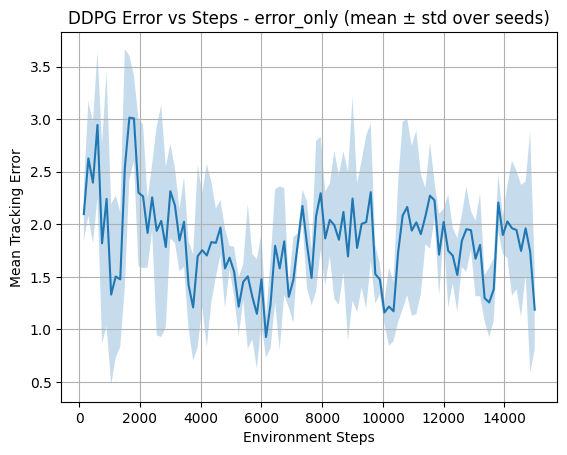

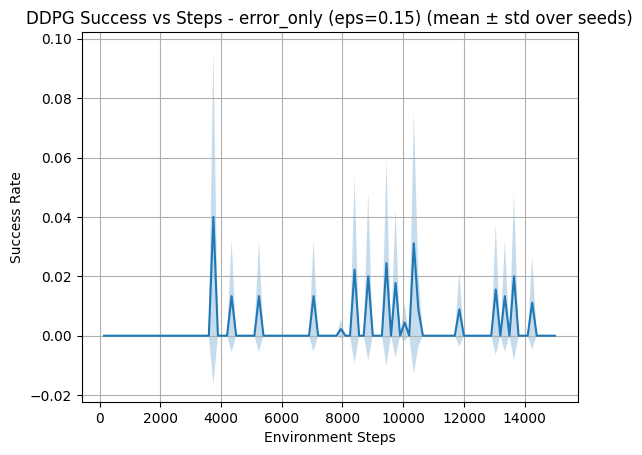

Training mode=ik_error seed=0 ...
Training mode=ik_error seed=1 ...
Training mode=ik_error seed=2 ...


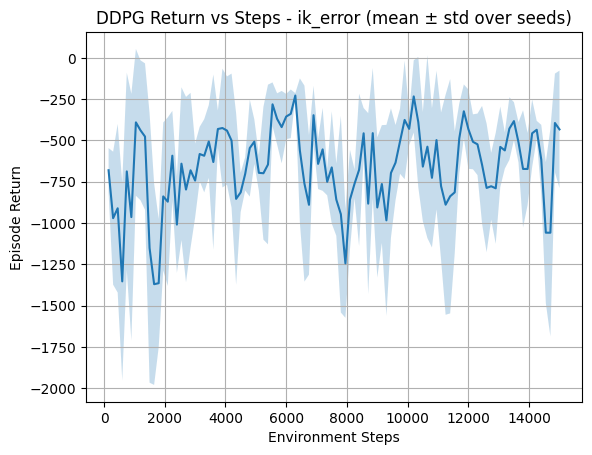

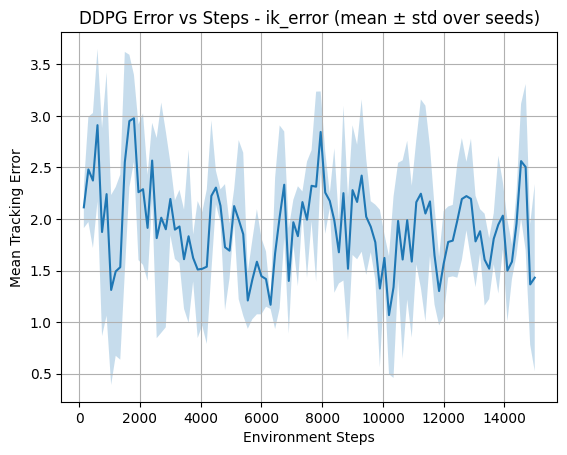

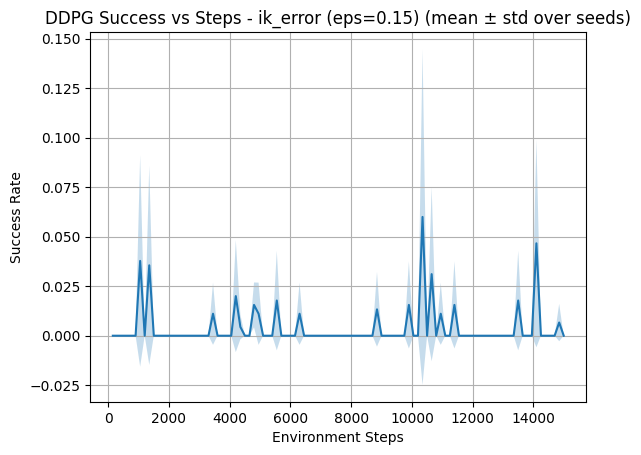

,Mode,Final Error (mean),Final Error (std),Final Return (mean),Final Return (std),Final Success (mean),Final Success (std)
1,plus_ee,1.772762,0.055214,-558.261573,24.012714,0.000667,0.000943
2,error_only,1.805704,0.108387,-585.533000,56.660678,0.003111,0.002455
3,ik_error,1.868916,0.042089,-630.791390,76.862287,0.005333,0.004989
0,minimal,1.912268,0.142800,-654.840060,102.824585,0.009556,0.010390


In [ ]:
df_h, raw_h = run_part_h(
    ReacherEnv=ReacherEnv,
    modes=("minimal", "plus_ee", "error_only", "ik_error"),  # یا فقط سه‌تا
    seeds=(0,1,2),
    episodes=100,
    eps_success=0.15,
    noise_type="ou",     # ثابت نگه دار برای مقایسه منصفانه
    final_window=10
)

df_h

Purpose of the ablation study

In this part, the goal is to understand how different state representations affect learning in DDPG. All agents use the same algorithm, hyperparameters, environment, and training length. The only difference is what information is provided as the state input. By comparing learning curves and final performance across these variants, we can identify which state representation makes learning easier, faster, and more stable.

Overall comparison across representations

Across all four state representations, learning does occur, but the quality and stability of learning differ noticeably. None of the representations produce perfect tracking or high success rates, which is consistent with earlier parts of the project. However, some representations clearly reduce tracking error faster and maintain better performance toward the end of training, while others show slower learning or higher variability across seeds.

Minimal state representation

The minimal representation (target position and joint states only) shows slow and unstable learning. Early in training, both return and tracking error fluctuate strongly, and although there is some improvement over time, the final mean error remains relatively high. The success rate stays close to zero for most of training, with only rare spikes late in training. This suggests that the agent struggles to infer how its actions affect the end-effector position when that information is not explicitly available. Learning is possible, but inefficient and noisy.

Minimal + end-effector representation

Adding the end-effector position significantly improves learning behavior. Compared to the minimal state, the error curve drops earlier and stays lower on average. Returns are also more stable, with fewer extreme negative episodes. The success rate, while still low in absolute terms, shows more frequent positive spikes. This indicates that explicitly providing the end-effector position helps the agent better understand the geometry of the task and reduces ambiguity in the state, leading to faster and more reliable learning.

Error-only (Cartesian error) representation

The error-only representation performs comparably to, and in some cases slightly better than, the minimal + end-effector case. The tracking error decreases more consistently during training, and the final error level is relatively low. The success rate shows occasional spikes similar to the plus-end-effector case. This representation focuses the agent directly on the task objective (reducing the distance to the target), which simplifies the learning problem. However, returns and error still fluctuate, indicating that removing absolute position information may limit long-term stability.

Inverse-kinematics error representation

The inverse-kinematics error representation shows mixed behavior. In some phases of training, it reaches low tracking errors comparable to the best representations, but overall it is less stable. Variance across seeds is higher, and learning curves show larger oscillations. While expressing the error in joint space is theoretically meaningful, the need to resolve inverse kinematics and the presence of multiple valid solutions likely introduce discontinuities that make learning harder for the neural network.

Learning speed comparison

In terms of learning speed, the minimal representation is clearly the slowest. The minimal + end-effector and error-only representations learn faster, reaching lower errors earlier in training. The inverse-kinematics error representation does not show a clear advantage in speed and appears more sensitive to noise and initialization. Overall, representations that provide direct task-relevant information in Cartesian space enable faster learning.

Final performance comparison

Looking at the later part of training, the lowest and most consistent tracking errors are achieved by the minimal + end-effector and error-only representations. The minimal representation finishes with higher error and weaker success rates. The inverse-kinematics representation does not outperform the Cartesian-based representations and shows higher variability. This suggests that providing either explicit end-effector position or direct Cartesian error is more effective than relying solely on joint-space information.

Interpretation of success rates

Success rates remain low across all representations, which is expected given the strict success threshold. However, relative differences are still meaningful. The minimal representation has the fewest success events, while the minimal + end-effector and error-only cases show more frequent success spikes. This indicates that richer or more task-focused state representations increase the chance of achieving very precise tracking, even if only briefly.

Final summary

In summary, the ablation study shows that state representation has a strong impact on learning quality in DDPG. The minimal state representation performs worst, learning slowly and unreliably. Adding end-effector information significantly improves both learning speed and final accuracy. Using Cartesian error directly also works well and simplifies the learning objective. The inverse-kinematics error representation does not provide clear benefits and introduces additional instability. Overall, representations that expose task-relevant Cartesian information lead to better and more stable learning.

Key takeaways

Best overall performance: Minimal + end-effector and error-only representations

Worst performance: Minimal representation (insufficient task information)

Most unstable: Inverse-kinematics error representation

Providing explicit Cartesian information helps the agent learn faster and generalize better

State design is as important as the learning algorithm itself in continuous control tasks

part 9

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def rollout_metrics(env, act_fn, episodes=30, eps_success=0.15, seed0=0):
    """
    Runs episodes with a given act_fn(s, info)->action and computes:
      - mean tracking error
      - success rate
      - control energy
      - smoothness
    Also returns episode returns for learning curves if you want.
    """
    all_err = []
    success_count = 0
    step_count = 0
    energy_sum = 0.0
    smooth_sum = 0.0
    ep_returns = []

    for ep in range(episodes):
        s, info = env.reset(seed=seed0 + ep)
        done = False
        prev_tau = None
        ep_ret = 0.0

        while not done:
            a = np.asarray(act_fn(s, info), dtype=np.float64).reshape(-1,)
            # clip to env bounds
            tau = np.clip(a, env.action_space.low, env.action_space.high)

            s2, r, terminated, truncated, info2 = env.step(tau)
            done = bool(terminated) or bool(truncated)

            # tracking error from info
            dist = float(np.linalg.norm(info2["p_end"] - info2["target"]))
            all_err.append(dist)
            if dist < eps_success:
                success_count += 1
            step_count += 1

            # control energy: sum ||tau||^2
            energy_sum += float(np.sum(tau**2))

            # smoothness: sum ||tau_t - tau_{t-1}||^2
            if prev_tau is not None:
                smooth_sum += float(np.sum((tau - prev_tau)**2))
            prev_tau = tau

            ep_ret += float(r)
            s, info = s2, info2

        ep_returns.append(ep_ret)

    mean_err = float(np.mean(all_err)) if len(all_err) else float("nan")
    success_rate = float(success_count / max(step_count, 1))
    control_energy = float(energy_sum)
    smoothness = float(smooth_sum)

    return {
        "mean_error": mean_err,
        "success_rate": success_rate,
        "control_energy": control_energy,
        "smoothness": smoothness,
        "avg_return": float(np.mean(ep_returns)) if len(ep_returns) else float("nan"),
    }

In [ ]:
def make_eval_env(ReacherEnv, seed=None):
    # default env: random static targets (as implemented in reset)
    return ReacherEnv(render_mode=None, seed=seed)

In [ ]:
def jacobian_2link(q, l1=1.0, l2=1.0):
    th1, th2 = q
    s1 = np.sin(th1); c1 = np.cos(th1)
    s12 = np.sin(th1+th2); c12 = np.cos(th1+th2)
    J = np.array([
        [-l1*s1 - l2*s12, -l2*s12],
        [ l1*c1 + l2*c12,  l2*c12]
    ], dtype=np.float64)
    return J

class CartesianPID:
    def __init__(self, env, kp=10.0, kd=2.0, ki=0.0):
        self.env = env
        self.kp, self.kd, self.ki = kp, kd, ki
        self.int_e = np.zeros(2, dtype=np.float64)

    def reset(self):
        self.int_e[:] = 0.0

    def __call__(self, s, info):
        # use env internal states for consistency
        q = self.env.unwrapped.q.copy()
        qd = self.env.unwrapped.q_d.copy()
        p = info["p_end"]
        target = info["target"]

        e = (target - p)
        self.int_e += e * self.env.unwrapped.dt

        # approximate end-effector velocity via Jacobian * qdot
        J = jacobian_2link(q, self.env.unwrapped.l1, self.env.unwrapped.l2)
        v = J @ qd

        # desired cartesian "force" (really a heuristic control signal)
        u = self.kp*e - self.kd*v + self.ki*self.int_e

        # map to torques: tau = J^T u
        tau = J.T @ u
        return tau

In [ ]:
def wrap_angle(a):
    return np.arctan2(np.sin(a), np.cos(a))

def two_link_ik_solutions(x, y, l1=1.0, l2=1.0):
    r2 = x*x + y*y
    c2 = (r2 - l1*l1 - l2*l2) / (2*l1*l2)
    if c2 < -1.0 or c2 > 1.0:
        return None
    th2a = np.arccos(c2)
    th2b = -np.arccos(c2)

    def th1(th2):
        k1 = l1 + l2*np.cos(th2)
        k2 = l2*np.sin(th2)
        return np.arctan2(y, x) - np.arctan2(k2, k1)

    return (th1(th2a), th2a), (th1(th2b), th2b)

class IKJointPD:
    def __init__(self, env, kp=30.0, kd=4.0):
        self.env = env
        self.kp, self.kd = kp, kd

    def reset(self):
        pass

    def __call__(self, s, info):
        q = self.env.unwrapped.q.copy()
        qd = self.env.unwrapped.q_d.copy()
        target = info["target"]
        sols = two_link_ik_solutions(float(target[0]), float(target[1]),
                                     self.env.unwrapped.l1, self.env.unwrapped.l2)
        if sols is None:
            th_star = q  # fallback
        else:
            (a1,a2),(b1,b2) = sols
            da = abs(wrap_angle(q[0]-a1)) + abs(wrap_angle(q[1]-a2))
            db = abs(wrap_angle(q[0]-b1)) + abs(wrap_angle(q[1]-b2))
            th_star = np.array([a1,a2]) if da <= db else np.array([b1,b2])

        e = np.array([wrap_angle(th_star[0]-q[0]), wrap_angle(th_star[1]-q[1])], dtype=np.float64)
        tau = self.kp*e - self.kd*qd
        return tau

In [ ]:
from collections import defaultdict

def discretize_state(obs, bins):
    # obs: [x_t, y_t, th1, th2, thd1, thd2]
    out = []
    for v, (lo, hi, n) in zip(obs, bins):
        v = float(np.clip(v, lo, hi))
        idx = int((v - lo) / (hi - lo + 1e-9) * n)
        idx = min(max(idx, 0), n-1)
        out.append(idx)
    return tuple(out)

class SARSAAgent:
    def __init__(self, action_set, alpha=0.1, gamma=0.99, eps=0.2, eps_min=0.05, eps_decay=0.995):
        self.Q = defaultdict(float)
        self.action_set = [np.asarray(a, dtype=np.float64) for a in action_set]
        self.alpha, self.gamma = alpha, gamma
        self.eps, self.eps_min, self.eps_decay = eps, eps_min, eps_decay

    def policy(self, s_key):
        if np.random.rand() < self.eps:
            return np.random.randint(len(self.action_set))
        # greedy
        qs = [self.Q[(s_key, ai)] for ai in range(len(self.action_set))]
        return int(np.argmax(qs))

    def update(self, s_key, a_idx, r, s2_key, a2_idx, done):
        q = self.Q[(s_key, a_idx)]
        target = r if done else (r + self.gamma * self.Q[(s2_key, a2_idx)])
        self.Q[(s_key, a_idx)] = q + self.alpha * (target - q)

    def decay_eps(self):
        self.eps = max(self.eps_min, self.eps * self.eps_decay)

def train_sarsa(ReacherEnv, seeds=(0,1,2), episodes=200, eps_success=0.15):
    # define bins for 6D obs
    bins = [
        (-2.0, 2.0, 8),   # x_t
        (-2.0, 2.0, 8),   # y_t
        (-np.pi, np.pi, 8),  # th1
        (-np.pi, np.pi, 8),  # th2
        (-10.0, 10.0, 6),    # thd1
        (-10.0, 10.0, 6),    # thd2
    ]

    tau = 2.0
    action_set = [
        (-tau, -tau), (-tau, 0.0), (-tau, tau),
        (0.0, -tau),  (0.0, 0.0),  (0.0, tau),
        (tau, -tau),  (tau, 0.0),  (tau, tau),
    ]

    curves = []
    final_metrics = []

    for sd in seeds:
        np.random.seed(sd)
        env = ReacherEnv(render_mode=None, seed=sd)
        agent = SARSAAgent(action_set, alpha=0.15, gamma=0.99, eps=0.3, eps_min=0.05, eps_decay=0.995)

        steps_log, err_log, succ_log = [], [], []
        global_step = 0

        for ep in range(episodes):
            obs, info = env.reset(seed=sd+ep)
            s_key = discretize_state(obs, bins)
            a_idx = agent.policy(s_key)

            done = False
            ep_err_sum = 0.0
            ep_succ = 0
            ep_t = 0

            while not done:
                action = agent.action_set[a_idx]
                obs2, r, terminated, truncated, info2 = env.step(action)
                done = bool(terminated) or bool(truncated)

                dist = float(np.linalg.norm(info2["p_end"] - info2["target"]))
                ep_err_sum += dist
                if dist < eps_success:
                    ep_succ += 1
                ep_t += 1
                global_step += 1

                s2_key = discretize_state(obs2, bins)
                a2_idx = agent.policy(s2_key)

                agent.update(s_key, a_idx, float(r), s2_key, a2_idx, done)

                obs, info = obs2, info2
                s_key, a_idx = s2_key, a2_idx

            agent.decay_eps()

            steps_log.append(global_step)
            err_log.append(ep_err_sum / max(ep_t,1))
            succ_log.append(ep_succ / max(ep_t,1))

        # evaluate SARSA greedy policy (eps=0) for metrics table
        agent.eps = 0.0
        eval_env = ReacherEnv(render_mode=None, seed=999)
        metrics = rollout_metrics(eval_env, act_fn=lambda s, info: agent.action_set[agent.policy(discretize_state(s, bins))],
                                  episodes=30, eps_success=eps_success, seed0=1000+sd)

        curves.append({"steps": np.array(steps_log), "err": np.array(err_log), "succ": np.array(succ_log)})
        final_metrics.append(metrics)
        env.close(); eval_env.close()

    return curves, final_metrics

In [ ]:
def train_ddpg_k_seeds(train_one_seed_fn, seeds=(0,1,2)):
    # train_one_seed_fn(seed) باید steps/returns/errors/success و agent را برگرداند
    runs = [train_one_seed_fn(sd) for sd in seeds]
    steps = runs[0]["steps"]
    returns = [r["returns"] for r in runs]
    errors  = [r["errors"] for r in runs]
    success = [r["success"] for r in runs]
    agents  = [r["agent"] for r in runs]
    return steps, returns, errors, success, agents

def plot_mean_std_curve(steps, curves, title, ylabel):
    M = np.stack(curves, axis=0)
    mean = M.mean(axis=0)
    std = M.std(axis=0)
    plt.figure()
    plt.plot(steps, mean)
    plt.fill_between(steps, mean-std, mean+std, alpha=0.25)
    plt.xlabel("Environment Steps")
    plt.ylabel(ylabel)
    plt.title(title + " (mean ± std over 3 seeds)")
    plt.grid(True)
    plt.show()

In [ ]:
def run_part_i(ReacherEnv,
               ddpg_train_one_seed,
               eps_success=0.15,
               ddpg_mode="plus_ee",
               sarsa_episodes=200,
               eval_episodes=30):

    # ---------- PID ----------
    env_pid = ReacherEnv(render_mode=None, seed=0)
    pid = CartesianPID(env_pid, kp=10.0, kd=2.0, ki=0.0)
    pid.reset()
    pid_metrics = rollout_metrics(
        env_pid,
        act_fn=lambda s, info: pid(s, info),
        episodes=eval_episodes,
        eps_success=eps_success,
        seed0=0
    )
    env_pid.close()

    # ---------- IK+PID ----------
    env_ik = ReacherEnv(render_mode=None, seed=1)
    ikpd = IKJointPD(env_ik, kp=30.0, kd=4.0)
    ikpd.reset()
    ik_metrics = rollout_metrics(
        env_ik,
        act_fn=lambda s, info: ikpd(s, info),
        episodes=eval_episodes,
        eps_success=eps_success,
        seed0=100
    )
    env_ik.close()

    # ---------- SARSA (train K=3 seeds + mean±std curves) ----------
    sarsa_curves, sarsa_final_metrics = train_sarsa(
        ReacherEnv,
        seeds=(0,1,2),
        episodes=sarsa_episodes,
        eps_success=eps_success
    )

    sarsa_steps = sarsa_curves[0]["steps"]
    plot_mean_std_curve(sarsa_steps, [c["err"] for c in sarsa_curves],
                        "SARSA Error vs Steps", "Mean Tracking Error")
    plot_mean_std_curve(sarsa_steps, [c["succ"] for c in sarsa_curves],
                        f"SARSA Success vs Steps (eps={eps_success})", "Success Rate")

    def agg(metrics_list):
        keys = ["mean_error","success_rate","control_energy","smoothness","avg_return"]
        out = {}
        for k in keys:
            vals = [m[k] for m in metrics_list]
            out[k+"_mean"] = float(np.mean(vals))
            out[k+"_std"]  = float(np.std(vals))
        return out

    sarsa_agg = agg(sarsa_final_metrics)

    # ---------- DDPG (train K=3 seeds + mean±std curves) ----------
    ddpg_steps, ddpg_returns, ddpg_errors, ddpg_success, ddpg_agents = train_ddpg_k_seeds(
        ddpg_train_one_seed, seeds=(0,1,2)
    )

    plot_mean_std_curve(ddpg_steps, ddpg_returns, "DDPG Return vs Steps", "Episode Return")
    plot_mean_std_curve(ddpg_steps, ddpg_errors,  "DDPG Error vs Steps", "Mean Tracking Error")
    plot_mean_std_curve(ddpg_steps, ddpg_success, f"DDPG Success vs Steps (eps={eps_success})", "Success Rate")

    # DDPG deterministic evaluation (FIXED: same state mode as training)
    ddpg_metrics_list = []
    for i, ag in enumerate(ddpg_agents):
        env_eval = ReacherEnv(render_mode=None, seed=2000+i)
        env_eval = StateAblationWrapper(env_eval, mode=ddpg_mode)

        m = rollout_metrics(
            env_eval,
            act_fn=lambda s, info, ag=ag: ag.act(s, add_noise=False),
            episodes=eval_episodes,
            eps_success=eps_success,
            seed0=3000+i*100
        )
        ddpg_metrics_list.append(m)
        env_eval.close()

    ddpg_agg = agg(ddpg_metrics_list)

    # ---------- Final table ----------
    rows = []
    rows.append({"Method":"PID", "Type":"Classical", **{
        "Mean Error": pid_metrics["mean_error"],
        "Success Rate": pid_metrics["success_rate"],
        "Control Energy": pid_metrics["control_energy"],
        "Smoothness": pid_metrics["smoothness"],
        "Avg Return": pid_metrics["avg_return"],
    }})
    rows.append({"Method":"IK+PID", "Type":"Classical", **{
        "Mean Error": ik_metrics["mean_error"],
        "Success Rate": ik_metrics["success_rate"],
        "Control Energy": ik_metrics["control_energy"],
        "Smoothness": ik_metrics["smoothness"],
        "Avg Return": ik_metrics["avg_return"],
    }})
    rows.append({"Method":"SARSA", "Type":"RL", **{
        "Mean Error": sarsa_agg["mean_error_mean"],
        "Success Rate": sarsa_agg["success_rate_mean"],
        "Control Energy": sarsa_agg["control_energy_mean"],
        "Smoothness": sarsa_agg["smoothness_mean"],
        "Avg Return": sarsa_agg["avg_return_mean"],
    }})
    rows.append({"Method":"DDPG", "Type":"RL", **{
        "Mean Error": ddpg_agg["mean_error_mean"],
        "Success Rate": ddpg_agg["success_rate_mean"],
        "Control Energy": ddpg_agg["control_energy_mean"],
        "Smoothness": ddpg_agg["smoothness_mean"],
        "Avg Return": ddpg_agg["avg_return_mean"],
    }})

    df_final = pd.DataFrame(rows)
    return df_final

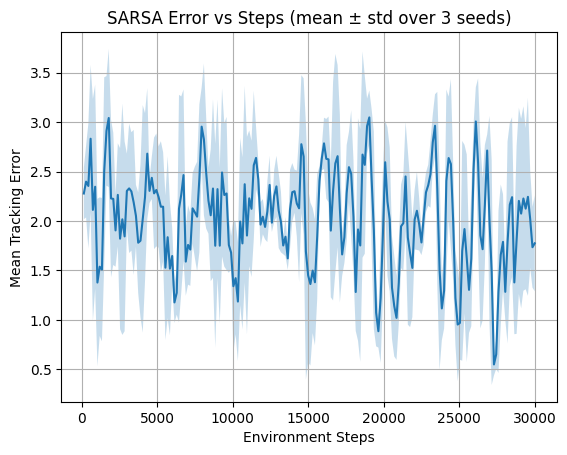

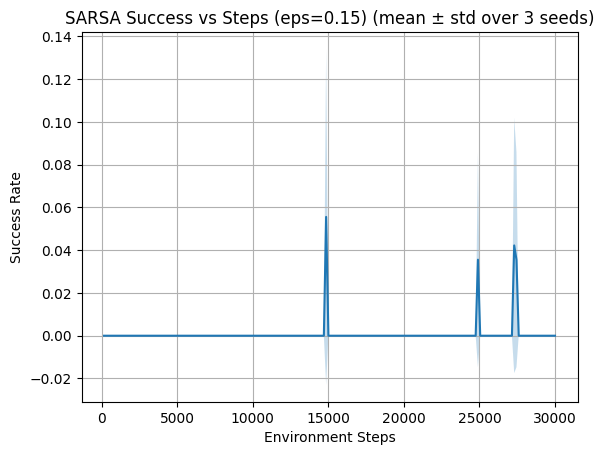

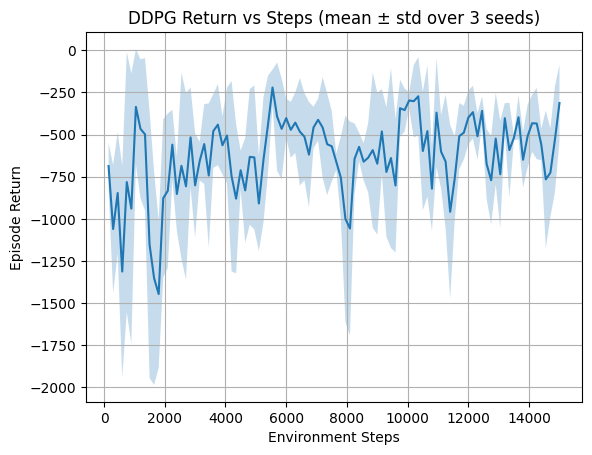

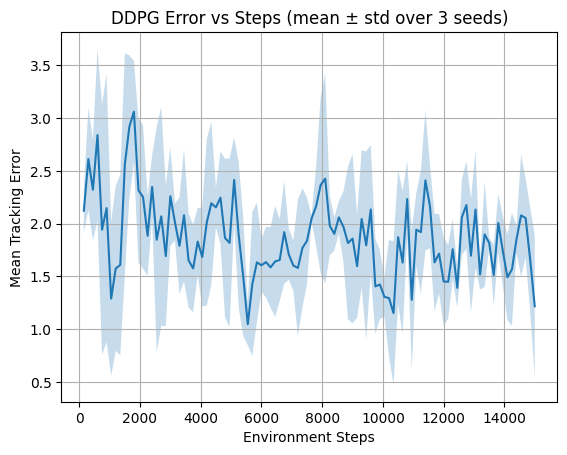

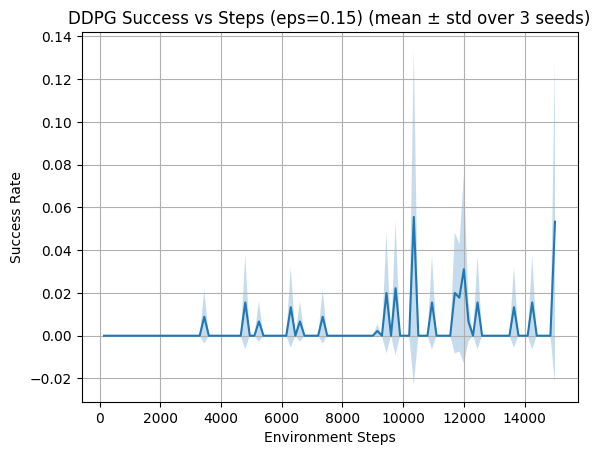

,Method,Type,Mean Error,Success Rate,Control Energy,Smoothness,Avg Return
0,PID,Classical,1.378143,0.044000,30410.740983,121.455819,-412.890107
1,IK+PID,Classical,1.344967,0.077333,26120.926679,350.036820,-416.692813
2,SARSA,RL,1.990916,0.001778,29229.333333,18256.000000,-680.240799
3,DDPG,RL,1.969310,0.006000,15264.275634,489.058805,-693.833246


In [ ]:
df_final = run_part_i(
    ReacherEnv=ReacherEnv,
    ddpg_train_one_seed=ddpg_train_one_seed,
    eps_success=0.15,
    ddpg_mode="plus_ee",
    sarsa_episodes=200,
    eval_episodes=30
)
df_final

Overall purpose of Part (i)

The goal of this section is to compare different control and learning methods using the same evaluation metrics, so that their strengths and weaknesses can be judged fairly. The methods include two classical controllers (PID and IK+PID) and two reinforcement learning methods (SARSA and DDPG). The comparison is based on tracking accuracy, success rate, control effort, smoothness of actions, and overall return.

Learning behavior over time (curves)
SARSA learning curves

From the SARSA error and success plots, the learning behavior is clearly unstable and inefficient. The tracking error remains high throughout training and fluctuates strongly, with no clear downward trend. This means SARSA does not consistently learn how to reduce the distance between the end-effector and the target.

The success rate is almost always zero, with only a few isolated spikes late in training. These spikes are rare and inconsistent, showing that SARSA occasionally finds a good action by chance rather than learning a reliable policy. Overall, SARSA struggles with this continuous control task and does not converge to a useful solution.

DDPG learning curves

DDPG shows a more structured learning behavior than SARSA. The tracking error starts high but gradually decreases and stabilizes at a lower level. Although fluctuations are still present, the average error is clearly lower than SARSA and more consistent over time.

The success rate for DDPG is low, but it is noticeably higher and more frequent than SARSA. Small success peaks appear more often in the second half of training, indicating that DDPG occasionally reaches the target region and is learning a partially effective control strategy. Compared to SARSA, DDPG benefits from continuous actions and function approximation.

Final quantitative comparison (table analysis)
Mean tracking error

Among all methods, IK+PID achieves the lowest mean tracking error, closely followed by PID. This shows that classical controllers, when well designed, are very effective at precise tracking in this environment.

DDPG performs significantly worse than PID-based controllers but slightly better than SARSA. This suggests that while DDPG can learn useful behaviors, it still cannot match the accuracy of model-based classical control within the given training budget.

Success rate

The highest success rate belongs to IK+PID, followed by PID. These methods consistently bring the end-effector close enough to the target to satisfy the success condition.

DDPG has a very low success rate, but it is still higher than SARSA. SARSA’s success rate is almost zero, confirming that it fails to solve the task reliably. This highlights the difficulty of applying discrete-action RL methods to continuous control problems.

Control energy

DDPG uses the least control energy among all methods. This indicates that its actions are generally smaller and more conservative. While this improves energy efficiency, it also contributes to weaker tracking performance.

PID and IK+PID use more energy, especially PID, because they actively correct errors using strong feedback. SARSA also consumes a large amount of energy, but without achieving good performance, meaning its control signals are inefficient.

Smoothness of control

PID produces the smoothest control actions, as expected from a classical feedback controller. IK+PID is less smooth due to joint-space corrections and inverse kinematics, but still remains stable.

DDPG has moderate smoothness. Its actions are smoother than SARSA but less smooth than PID-based methods. SARSA has extremely poor smoothness, indicating abrupt and inconsistent action changes, which is another sign of unstable learning.

Average return

PID and IK+PID achieve the best average returns, reflecting their low tracking error and consistent behavior. DDPG’s average return is significantly lower, and SARSA performs worst overall.

This ranking aligns well with the error and success metrics and confirms that average return is a meaningful global indicator of performance in this task.

Overall comparison and interpretation

Classical controllers clearly outperform reinforcement learning methods in this setting. PID and IK+PID benefit from explicit structure, known system behavior, and direct error feedback. Among them, IK+PID provides the best balance between accuracy and success rate.

DDPG shows promise: it learns smoother and more energy-efficient control than SARSA and achieves non-zero success rates. However, its performance is still limited by training time, exploration noise, and the complexity of the task.

SARSA is not well suited for this problem. Its discrete nature, poor stability, and inefficient exploration make it unable to learn a reliable policy for continuous torque control.

Final summary

This experiment shows that model-based classical control remains the strongest baseline for robotic reaching tasks. Reinforcement learning, especially DDPG, can learn meaningful behaviors but requires careful tuning and more training to approach classical performance. Discrete RL methods like SARSA are not appropriate for this type of continuous control problem.

Key takeaways

IK+PID is the best overall method in terms of accuracy and success rate.

PID is simple, stable, and very effective, especially in smoothness.

DDPG is more energy-efficient but less accurate and less reliable.

SARSA performs poorly and fails to converge reliably.

For continuous robotic control, algorithm choice matters more than training time.